# Import Statements

In [2]:
import os
import librosa
import numpy as np
import sounddevice as sd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle

# Loading the Dataset

In [2]:
dataset_path = './genres_original/'

In [3]:
data_paths = []
labels = []
genres = os.listdir(dataset_path)  # List of genre names

In [4]:
for genre in genres:
    genre_folder = os.path.join(dataset_path, genre)
    if os.path.isdir(genre_folder):  # Check if it's a directory
        for audio_file in os.listdir(genre_folder):
            audio_path = os.path.join(genre_folder, audio_file)
            data_paths.append(audio_path)
            labels.append(genre)


In [5]:
data_paths

['./genres_original/blues\\blues.00000.wav',
 './genres_original/blues\\blues.00001.wav',
 './genres_original/blues\\blues.00002.wav',
 './genres_original/blues\\blues.00003.wav',
 './genres_original/blues\\blues.00004.wav',
 './genres_original/blues\\blues.00005.wav',
 './genres_original/blues\\blues.00006.wav',
 './genres_original/blues\\blues.00007.wav',
 './genres_original/blues\\blues.00008.wav',
 './genres_original/blues\\blues.00009.wav',
 './genres_original/blues\\blues.00010.wav',
 './genres_original/blues\\blues.00011.wav',
 './genres_original/blues\\blues.00012.wav',
 './genres_original/blues\\blues.00013.wav',
 './genres_original/blues\\blues.00014.wav',
 './genres_original/blues\\blues.00015.wav',
 './genres_original/blues\\blues.00016.wav',
 './genres_original/blues\\blues.00017.wav',
 './genres_original/blues\\blues.00018.wav',
 './genres_original/blues\\blues.00019.wav',
 './genres_original/blues\\blues.00020.wav',
 './genres_original/blues\\blues.00021.wav',
 './genres

In [6]:
len(data_paths), len(labels)

(1000, 1000)

# Pre Processing

In [7]:
# Loading the audio file
audio, sr = librosa.load(data_paths[0])
# Play the audio
# sd.play(audio, sr)
# sd.wait()  # Wait until the audio finishes playing

In [8]:
# Trimming any leading or trailing silence
audio_trimmed, _ = librosa.effects.trim(audio)
# Play the audio
# sd.play(audio, sr)
# sd.wait()  # Wait until the audio finishes playing

In [9]:
# Making Sure that the audio file is 30 Seconds 
desired_length = 30 * sr  # For 5 seconds
if len(audio) > desired_length:
    audio = audio_trimmed[:desired_length]  # Truncate
else:
    audio = np.pad(audio_trimmed, (0, max(0, desired_length - len(audio))), mode='constant')  # Pad

# Play the audio
# sd.play(audio, sr)
# sd.wait()  # Wait until the audio finishes playing

In [10]:
len(audio)

661500

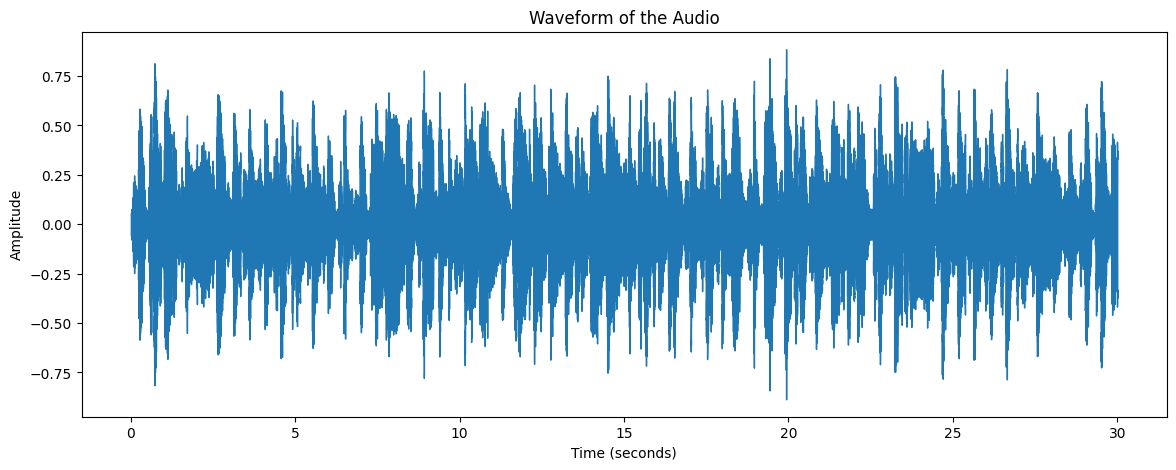

In [13]:
# Plot the waveform
plt.figure(figsize=(14, 5))
librosa.display.waveshow(audio, sr=sr)
plt.title('Waveform of the Audio')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.show()

# Play the audio
sd.play(audio, sr)
sd.wait()  # Wait until the audio finishes playing

# Extract Features

In [17]:
def PreProcessing(audio_file):
    audio, sr = librosa.load(audio_file, sr = 22059)
    audio_trimmed, _ = librosa.effects.trim(audio)
    desired_length = 30 * sr  # For 30 seconds
    if len(audio) > desired_length:
        audio = audio_trimmed[:desired_length]  # Truncate
    else:
        audio = np.pad(audio_trimmed, (0, max(0, desired_length - len(audio))), mode='constant')  # Pad
    return audio, sr

In [18]:
# Calculate features
def extract_features(y, sr):
    # 1. Chroma Features
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_stft_mean = np.mean(chroma_stft, axis=1)
    chroma_stft_mean = np.mean(chroma_stft_mean)
    chroma_stft_var = np.var(chroma_stft, axis=1)
    chroma_stft_var = np.mean(chroma_stft_var)
    
    # 2. RMS (Root Mean Square) Energy
    rms = librosa.feature.rms(y=y)
    rms_mean = np.mean(rms)
    rms_var = np.var(rms)
    
    # 3. Spectral Centroid
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_centroid_mean = np.mean(spectral_centroid)
    spectral_centroid_var = np.var(spectral_centroid)
    
    # 4. Spectral Bandwidth
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_bandwidth_mean = np.mean(spectral_bandwidth)
    spectral_bandwidth_var = np.var(spectral_bandwidth)
    
    # 5. Spectral Rolloff
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rolloff_mean = np.mean(rolloff)
    rolloff_var = np.var(rolloff)
    
    # 6. Zero-Crossing Rate
    zero_crossing_rate = librosa.feature.zero_crossing_rate(y=y)
    zero_crossing_rate_mean = np.mean(zero_crossing_rate)
    zero_crossing_rate_var = np.var(zero_crossing_rate)
    
    # 7. Harmony
    harmony = librosa.effects.harmonic(y=y)
    harmony_mean = np.mean(harmony)
    harmony_var = np.var(harmony)
    
    # 8. Tempo
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    tempo, _ = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)
    
    # 9. MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    mfcc_means = np.mean(mfccs, axis=1)
    mfcc_vars = np.var(mfccs, axis=1)

    # 10. Perceptual Spread 
    perceptual_spread = librosa.feature.spectral_contrast(y=y, sr=sr)
    perceptr_mean = np.mean(perceptual_spread)
    perceptr_var = np.var(perceptual_spread)
    
    # Creating features dictionary
    features = {
        'length': len(y),
        'chroma_stft_mean': chroma_stft_mean,
        'chroma_stft_var': chroma_stft_var,
        'rms_mean': rms_mean,
        'rms_var': rms_var,
        'spectral_centroid_mean': spectral_centroid_mean,
        'spectral_centroid_var': spectral_centroid_var,
        'spectral_bandwidth_mean': spectral_bandwidth_mean,
        'spectral_bandwidth_var': spectral_bandwidth_var,
        'rolloff_mean': rolloff_mean,
        'rolloff_var': rolloff_var,
        'zero_crossing_rate_mean': zero_crossing_rate_mean,
        'zero_crossing_rate_var': zero_crossing_rate_var,
        'harmony_mean': harmony_mean,
        'harmony_var': harmony_var,
        'tempo': tempo,
        'perceptr_mean': perceptr_mean, 
        'perceptr_var': perceptr_var,  
        **{f'mfcc{i+1}_mean': mfcc_means[i] for i in range(20)},
        **{f'mfcc{i+1}_var': mfcc_vars[i] for i in range(20)},
    }
    
    return features

{'length': 661770, 'chroma_stft_mean': np.float32(0.3500631), 'chroma_stft_var': np.float32(0.08505856), 'rms_mean': np.float32(0.13017906), 'rms_var': np.float32(0.0028295983), 'spectral_centroid_mean': np.float64(1784.7088617429229), 'spectral_centroid_var': np.float64(130171.76809868737), 'spectral_bandwidth_mean': np.float64(2002.5436292192635), 'spectral_bandwidth_var': np.float64(86015.55301957023), 'rolloff_mean': np.float64(3807.3180376305104), 'rolloff_var': np.float64(900345.222752765), 'zero_crossing_rate_mean': np.float64(0.08306974453789637), 'zero_crossing_rate_var': np.float64(0.0007632822741050764), 'harmony_mean': np.float32(-4.253687e-05), 'harmony_var': np.float32(0.008163943), 'tempo': array([123.09709821]), 'mfcc1_mean': np.float32(-113.576614), 'mfcc2_mean': np.float32(121.49447), 'mfcc3_mean': np.float32(-19.095407), 'mfcc4_mean': np.float32(42.272224), 'mfcc5_mean': np.float32(-6.284057), 'mfcc6_mean': np.float32(18.540144), 'mfcc7_mean': np.float32(-13.610485),

# EDA

## Waveform Plot
Visualizing the Plot to see the amplitude of the audio over time

In [19]:
genres

['blues',
 'classical',
 'country',
 'disco',
 'hiphop',
 'jazz',
 'metal',
 'pop',
 'reggae',
 'rock']

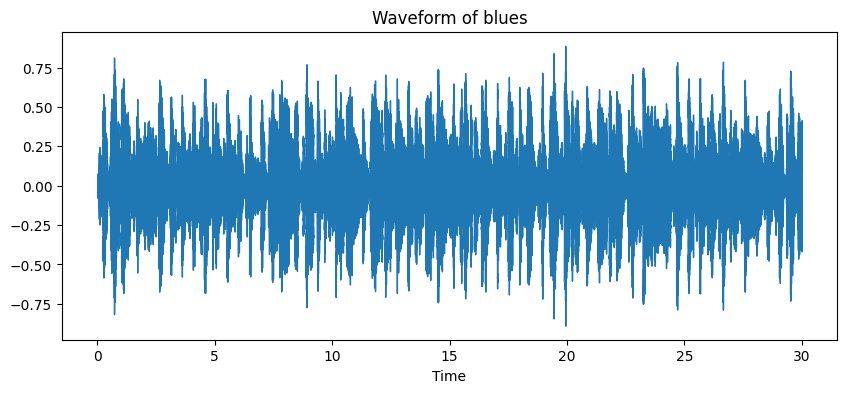

In [20]:
audio, sr = PreProcessing(data_paths[0])
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr)
plt.title(f'Waveform of {genres[0]}')
plt.show()

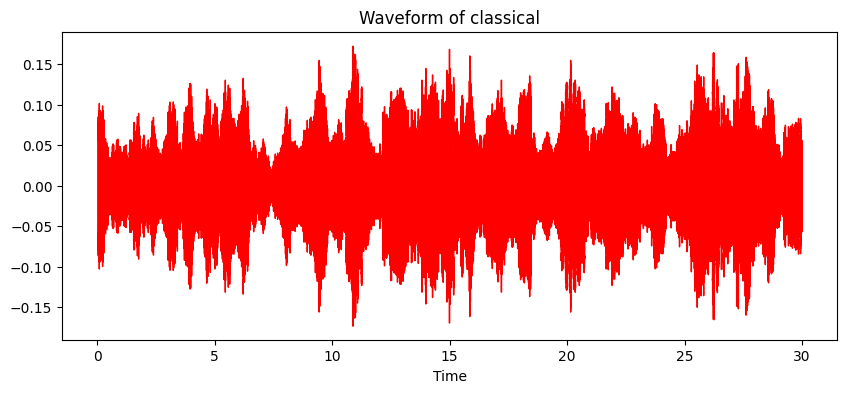

In [21]:
audio, sr = PreProcessing(data_paths[101])
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr, color = "red")
plt.title(f'Waveform of {genres[1]}')
plt.show()

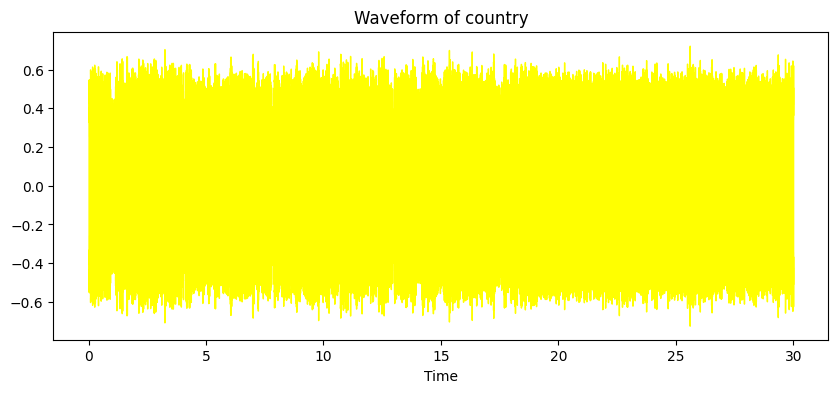

In [22]:
audio, sr = PreProcessing(data_paths[201])
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr, color = "yellow")
plt.title(f'Waveform of {genres[2]}')
plt.show()

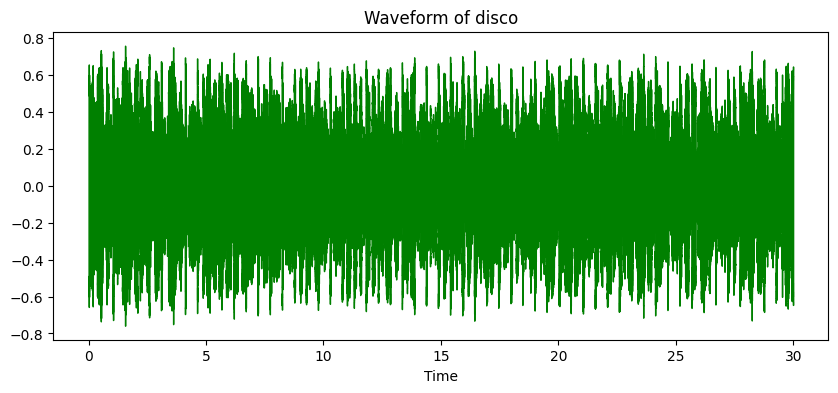

In [23]:
audio, sr = PreProcessing(data_paths[301])
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr, color = "green")
plt.title(f'Waveform of {genres[3]}')
plt.show()

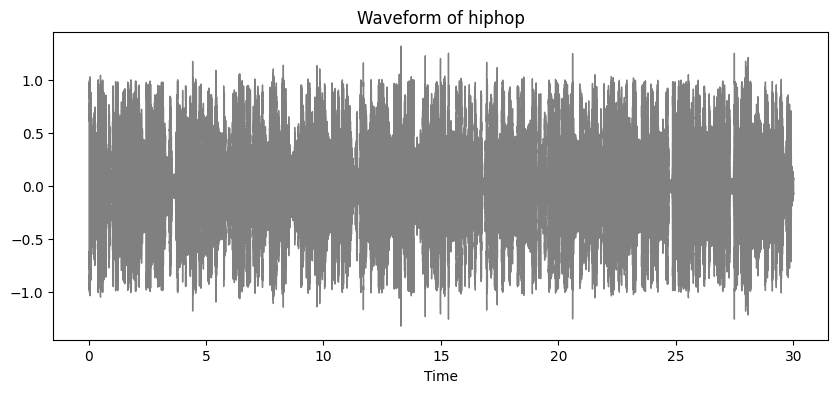

In [24]:
audio, sr = PreProcessing(data_paths[401])
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr, color = "gray")
plt.title(f'Waveform of {genres[4]}')
plt.show()

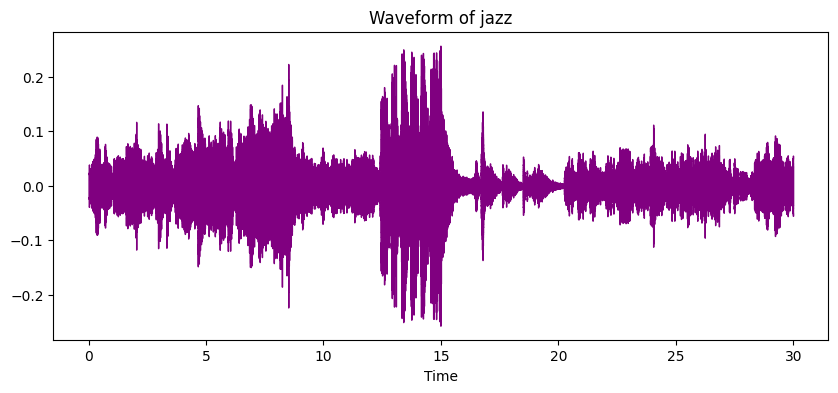

In [25]:
audio, sr = PreProcessing(data_paths[501])
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr, color = "purple")
plt.title(f'Waveform of {genres[5]}')
plt.show()

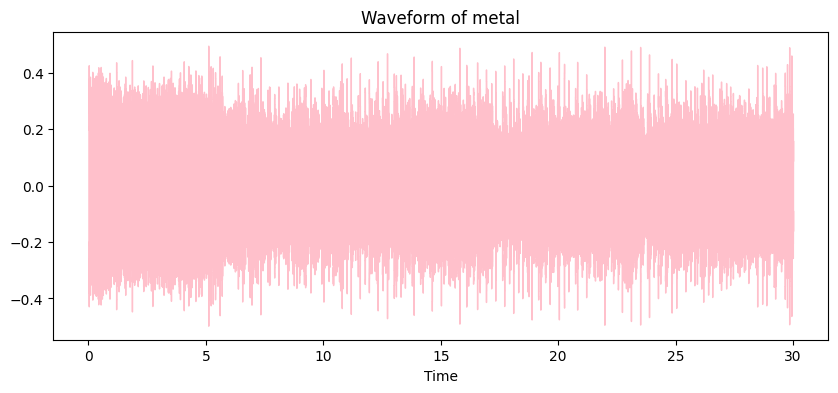

In [26]:
audio, sr = PreProcessing(data_paths[601])
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr, color = "pink")
plt.title(f'Waveform of {genres[6]}')
plt.show()

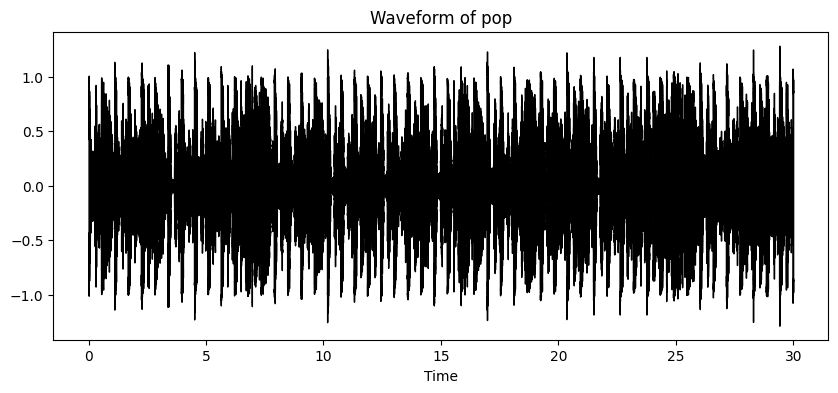

In [27]:
audio, sr = PreProcessing(data_paths[701])
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr, color = "black")
plt.title(f'Waveform of {genres[7]}')
plt.show()

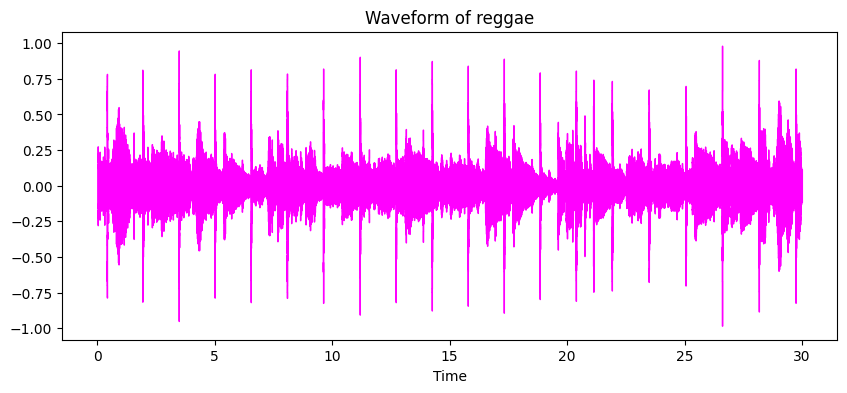

In [28]:
audio, sr = PreProcessing(data_paths[801])
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr, color = "magenta")
plt.title(f'Waveform of {genres[8]}')
plt.show()

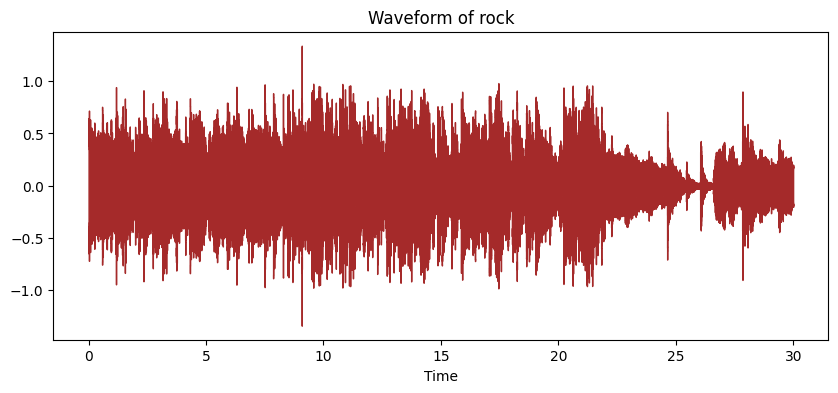

In [29]:
audio, sr = PreProcessing(data_paths[901])
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr, color = "brown")
plt.title(f'Waveform of {genres[9]}')
plt.show()

Most of the songs have a high level of amplitude as shown by their waveforms.

## Spectogram
To visualize the frequency of the signal.

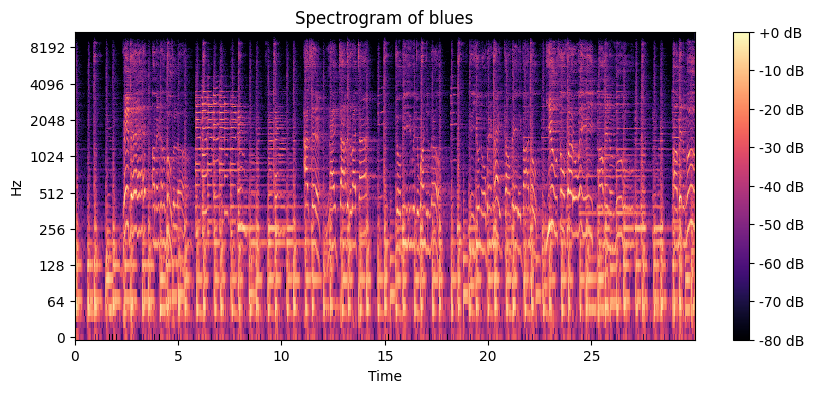

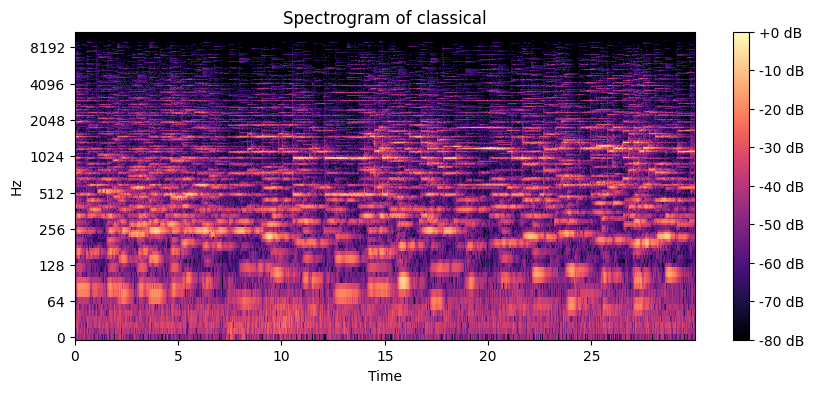

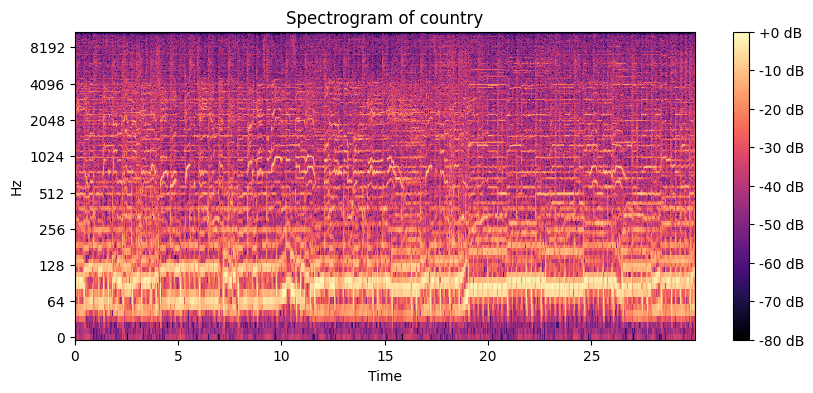

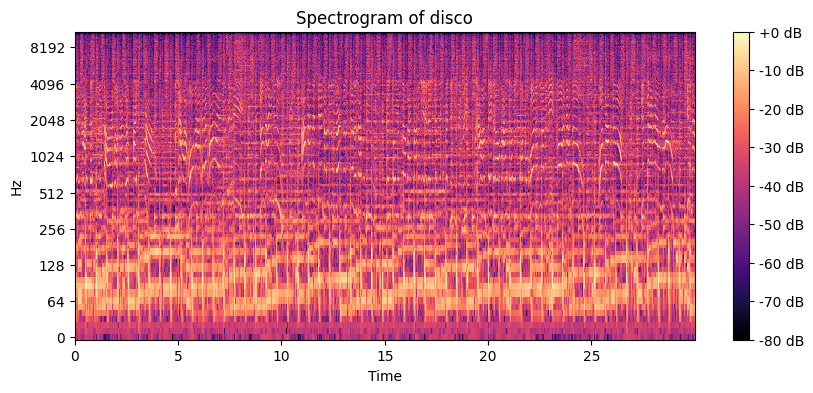

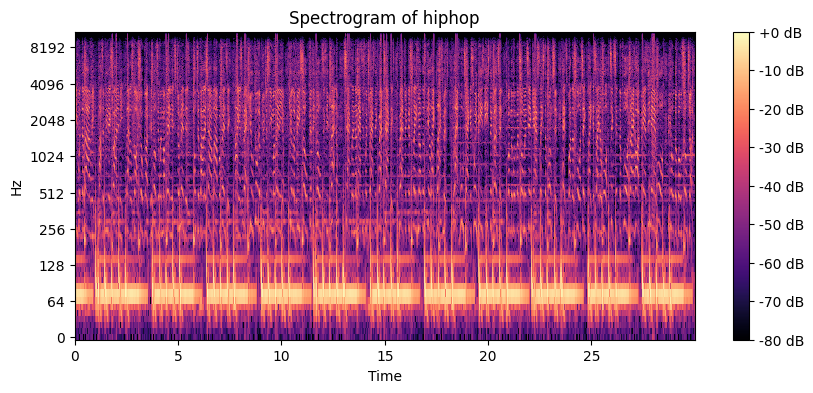

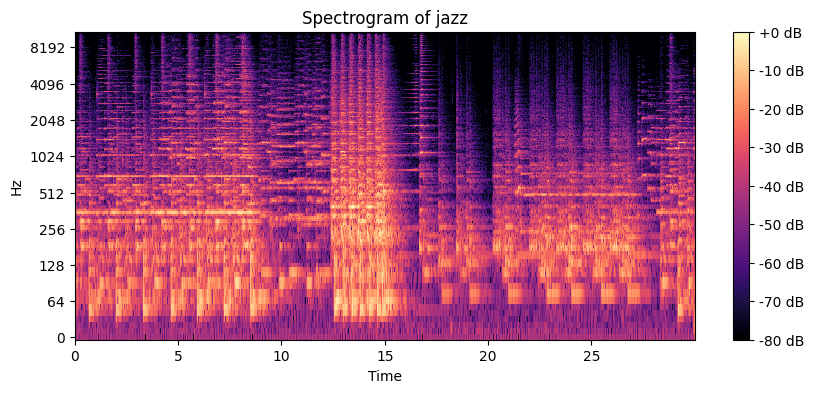

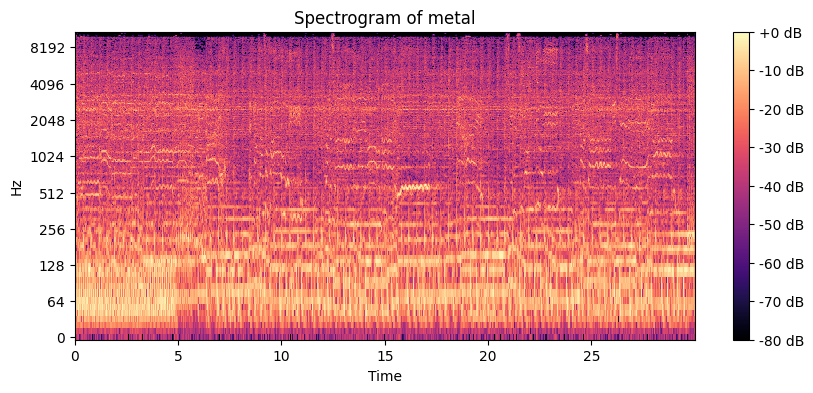

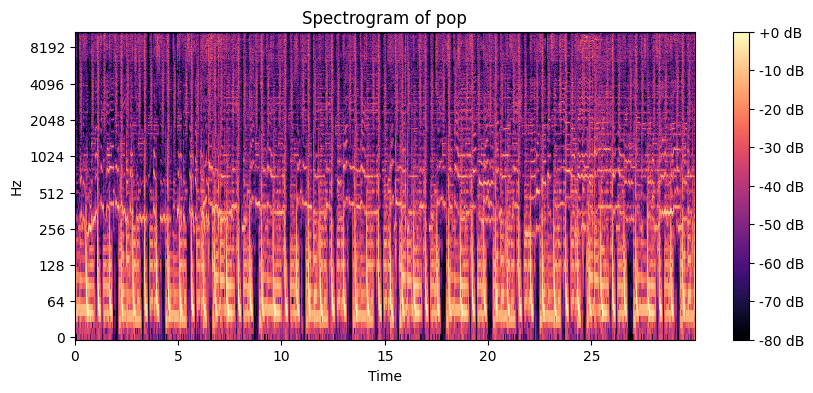

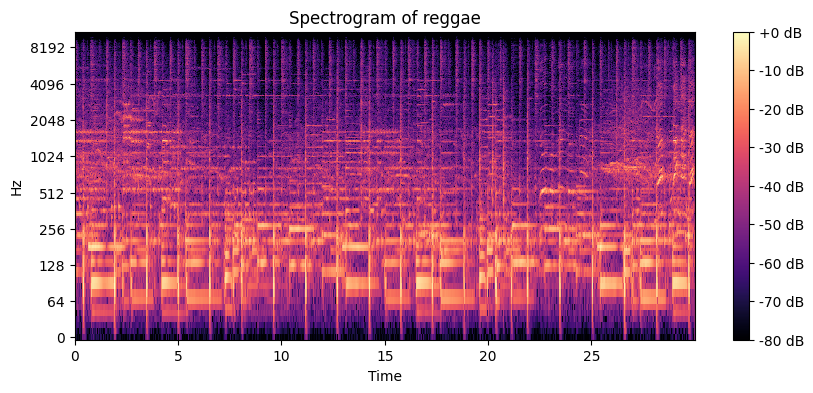

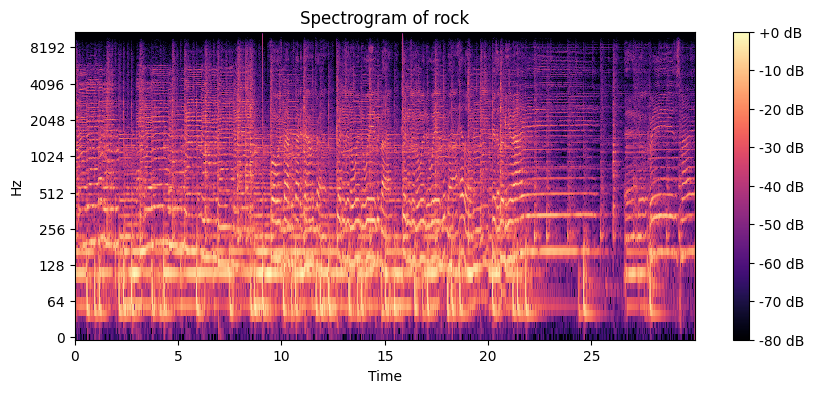

In [30]:
file_count = 1
for i, genre in enumerate(genres):
    audio, sr = PreProcessing(data_paths[file_count])
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Spectrogram of {genre}')
    plt.show()
    file_count += 100

## Mel Spectogram

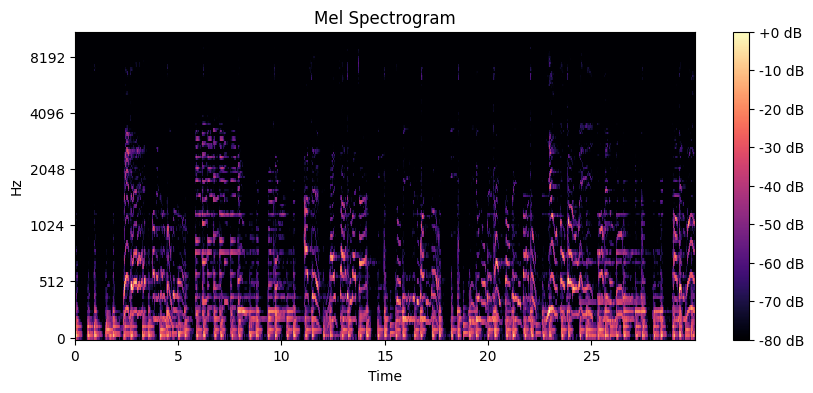

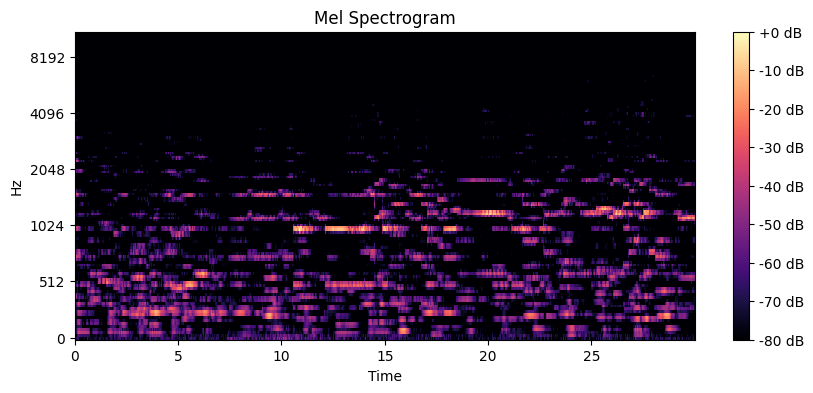

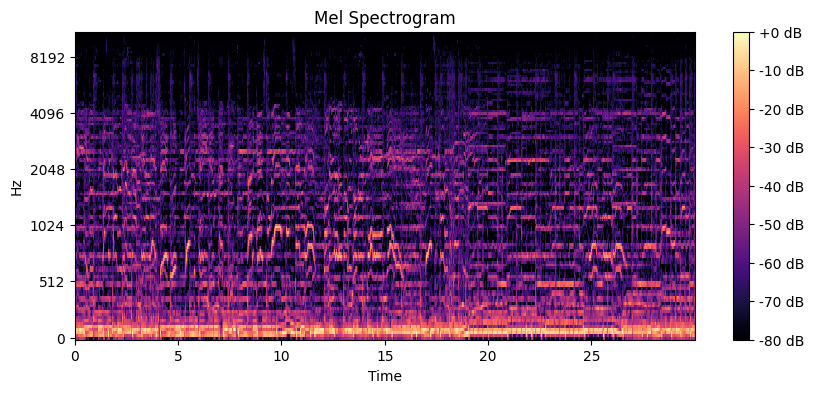

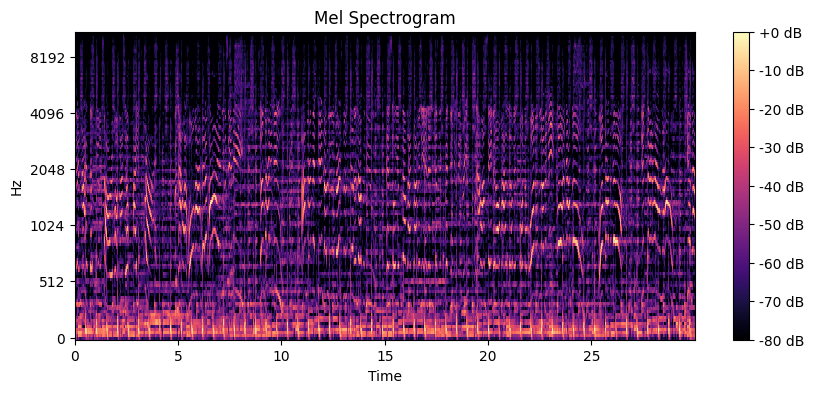

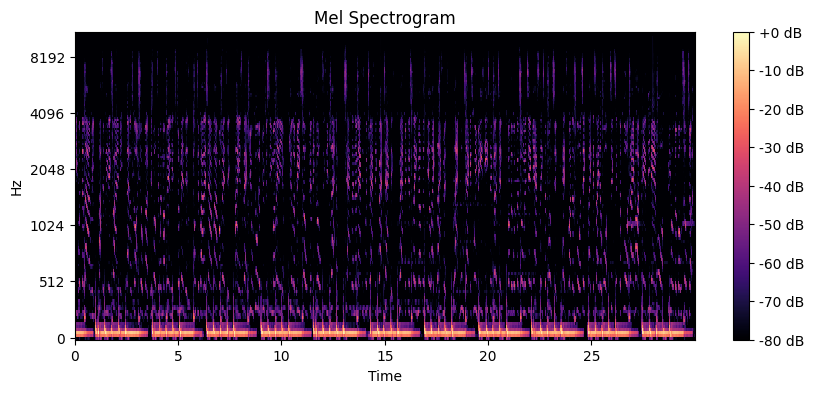

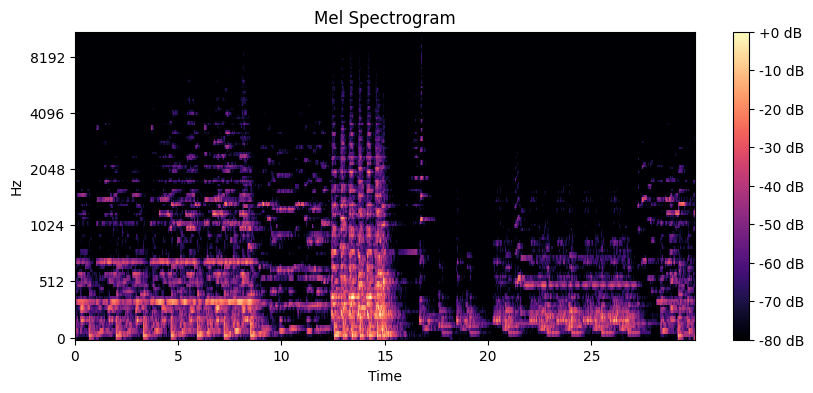

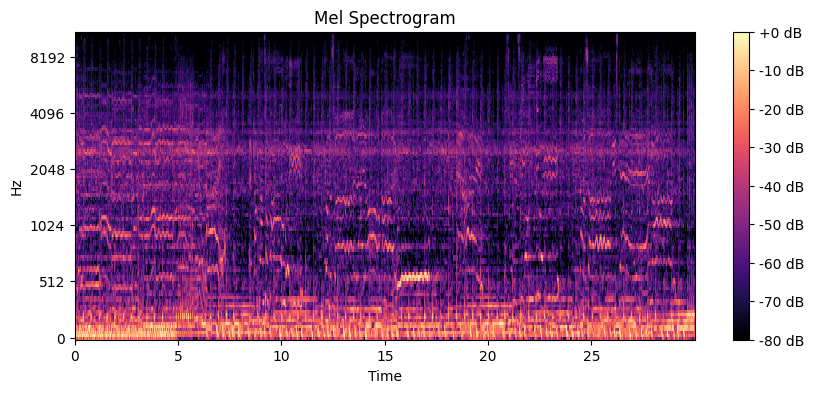

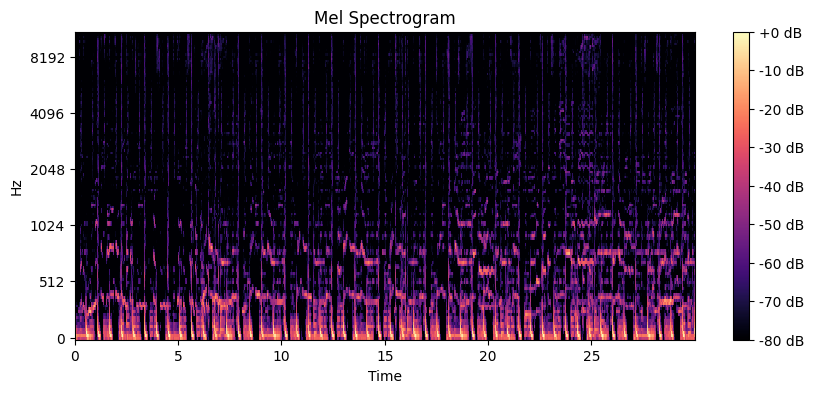

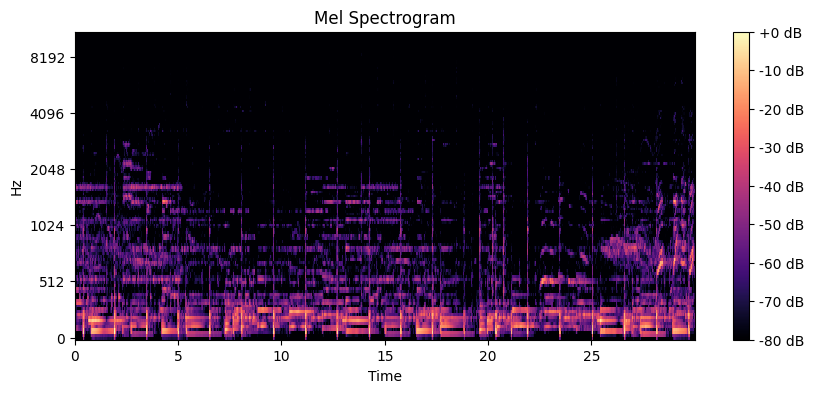

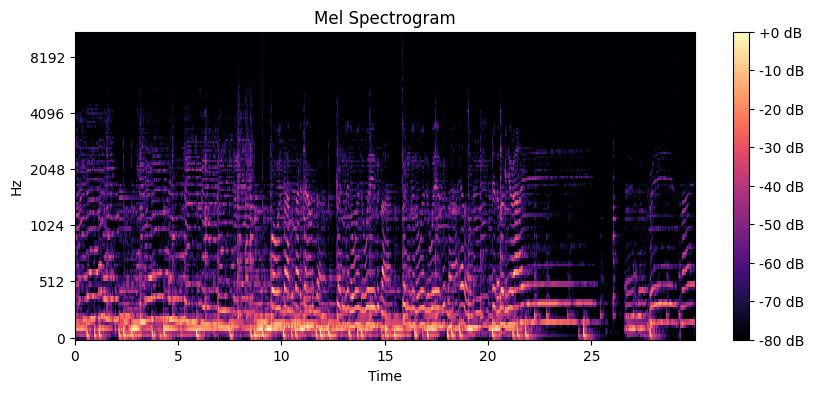

In [31]:
file_count = 1
for i, genre in enumerate(genres):
    audio, sr = PreProcessing(data_paths[file_count])
    mel_spect = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_spect_db = librosa.amplitude_to_db(mel_spect, ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spect_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel Spectrogram')
    plt.show()
    file_count += 100

**Spectrogram**: 

This Shows a grid where lower frequencies are spread out more at the bottom and higher frequencies compressed towards the top.

**Mel Spectrogram**: 

The grid is warped so that low frequencies (which humans are more sensitive to) are spread out, and higher frequencies are compressed.

# PrePearing The Dataset

The extracted features are already available which we can use to create a Neural Network.

## Loading the features

In [41]:
# Load the dataset
df = pd.read_csv('features_30_sec.csv')

# Preview the first few rows
df.head()


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [42]:
# Get the summary of the DataFrame
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 1000 non-null   object 
 1   length                   1000 non-null   int64  
 2   chroma_stft_mean         1000 non-null   float64
 3   chroma_stft_var          1000 non-null   float64
 4   rms_mean                 1000 non-null   float64
 5   rms_var                  1000 non-null   float64
 6   spectral_centroid_mean   1000 non-null   float64
 7   spectral_centroid_var    1000 non-null   float64
 8   spectral_bandwidth_mean  1000 non-null   float64
 9   spectral_bandwidth_var   1000 non-null   float64
 10  rolloff_mean             1000 non-null   float64
 11  rolloff_var              1000 non-null   float64
 12  zero_crossing_rate_mean  1000 non-null   float64
 13  zero_crossing_rate_var   1000 non-null   float64
 14  harmony_mean             

In [44]:
# Get basic statistics of numerical columns
df.describe()

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,662030.846000,0.378682,0.086340,0.130930,0.003051,2201.780898,4.696916e+05,2242.541070,137079.155165,4571.549304,...,1.148144,60.730958,-3.966028,62.633624,0.507696,63.712586,-2.328761,66.231930,-1.095348,70.126096
std,1784.073992,0.081705,0.007735,0.065683,0.003634,715.960600,4.008995e+05,526.316473,96455.666326,1574.791602,...,4.578948,33.781951,4.549697,33.479172,3.869105,34.401977,3.755957,37.174631,3.837007,45.228512
min,660000.000000,0.171939,0.044555,0.005276,0.000004,570.040355,7.911251e+03,898.066208,10787.185064,749.140636,...,-15.693844,9.169314,-17.234728,13.931521,-11.963694,15.420555,-18.501955,13.487622,-19.929634,7.956583
25%,661504.000000,0.319562,0.082298,0.086657,0.000942,1627.697311,1.843505e+05,1907.240605,67376.554428,3380.069642,...,-1.863280,40.376442,-7.207225,40.830875,-2.007015,41.884240,-4.662925,41.710184,-3.368996,42.372865
50%,661794.000000,0.383148,0.086615,0.122443,0.001816,2209.263090,3.384862e+05,2221.392843,111977.548036,4658.524473,...,1.212809,52.325077,-4.065605,54.717674,0.669643,54.804890,-2.393862,57.423059,-1.166289,59.186117
75%,661794.000000,0.435942,0.091256,0.175682,0.003577,2691.294667,6.121479e+05,2578.469836,182371.576801,5533.810460,...,4.359662,71.691755,-0.838737,75.040838,3.119212,75.385832,0.150573,78.626444,1.312615,85.375374
max,675808.000000,0.663685,0.108111,0.397973,0.027679,4435.243901,3.036843e+06,3509.646417,694784.811549,8677.672688,...,13.457150,392.932373,11.482946,406.058868,15.388390,332.905426,14.694924,393.161987,15.369627,506.065155


In [47]:
# Check for missing values
missing_values = df.isnull().sum()
print(missing_values)

filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8_mean                 0
mfcc8_var     

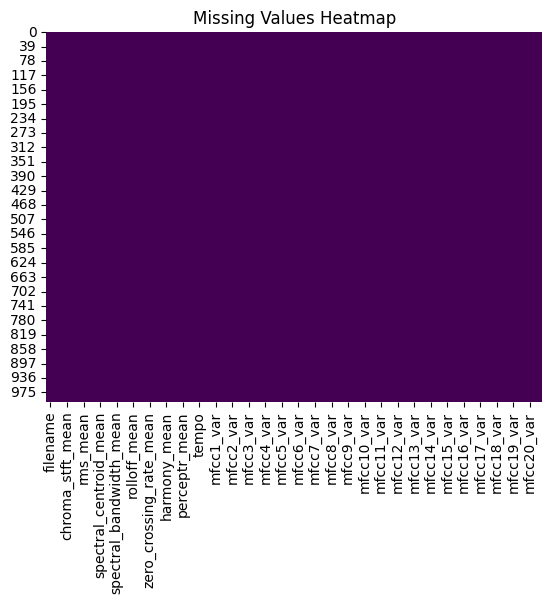

In [48]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

There are no null values in the given dataset.

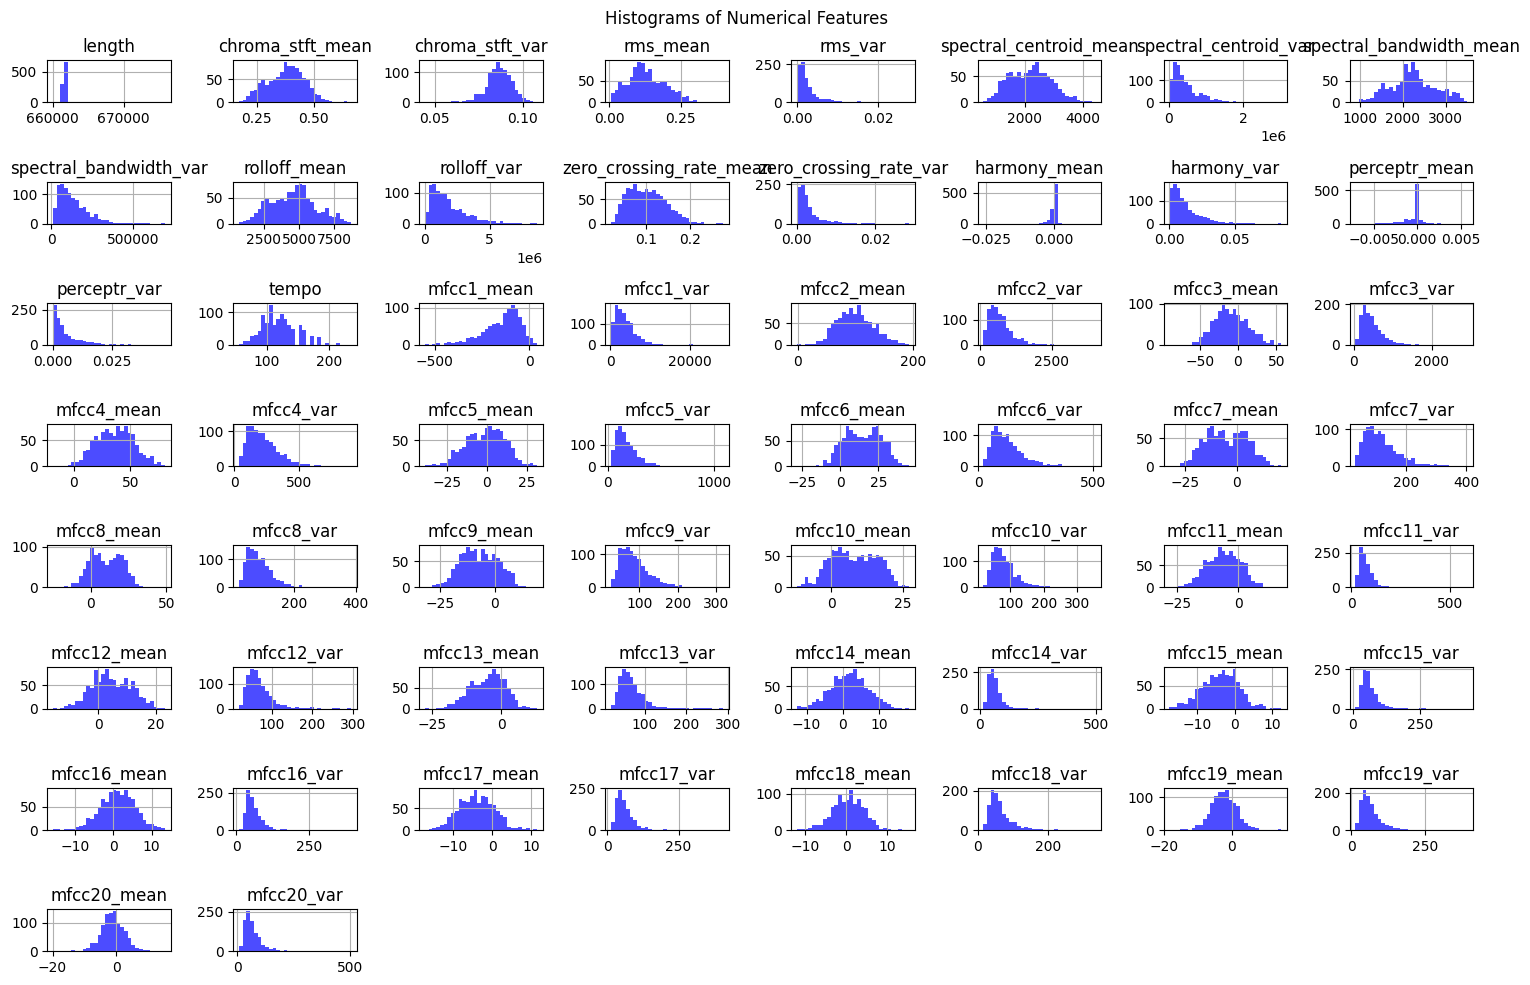

In [51]:
# Plot histograms for all numerical features
df.hist(bins=30, figsize=(15, 10), color='blue', alpha=0.7)
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout()
plt.show()

In [60]:
# Encoding the Target Variables
df['label'].unique()

array(['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz',
       'metal', 'pop', 'reggae', 'rock'], dtype=object)

In [61]:
genre_mapping = {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5,
                'metal': 6, 'pop': 7, 'reggae': 8, 'rock':9}

In [64]:
df['genre_mapped'] = df['label'].map(genre_mapping)
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label,genre_mapped
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues,0
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues,0
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues,0
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues,0
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues,0


In [67]:
# Dropping Columns that are not necessary
drop_columns = ['filename', 'label']
df2 = df.drop(drop_columns, axis = 1)
df2.head()

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,genre_mapped
0,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,3805.839606,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,0
1,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,3550.522098,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,0
2,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,3042.260232,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,0
3,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,2184.745799,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,0
4,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,3579.757627,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,0


In [72]:
# Compute the correlation matrix
correlation_matrix = df2.corr()
correlation_matrix


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,genre_mapped
length,1.000000,0.017426,0.073979,0.101801,0.116661,0.052175,0.121994,0.062503,0.118993,0.040363,...,0.025483,0.039179,0.003457,-0.025331,0.014822,0.010576,0.045884,0.014803,0.050338,-0.062194
chroma_stft_mean,0.017426,1.000000,-0.461729,0.499926,0.261544,0.615728,0.285926,0.517710,0.041088,0.598122,...,-0.452955,-0.163474,-0.456298,0.269935,-0.478452,-0.089509,-0.501768,0.281965,-0.548577,0.366451
chroma_stft_var,0.073979,-0.461729,1.000000,-0.078777,0.290138,-0.246441,0.305819,-0.036896,0.346907,-0.168721,...,0.361752,0.205117,0.389468,-0.239597,0.378200,0.184323,0.365291,-0.231715,0.333581,-0.082835
rms_mean,0.101801,0.499926,-0.078777,1.000000,0.607399,0.510154,0.324077,0.530017,0.099830,0.537902,...,-0.160347,-0.029562,-0.163490,0.118239,-0.164834,0.031297,-0.207680,0.124413,-0.252434,0.213968
rms_var,0.116661,0.261544,0.290138,0.607399,1.000000,0.347831,0.583353,0.402333,0.320793,0.368570,...,0.091863,0.168169,0.100234,-0.002585,0.058050,0.186953,0.049879,0.029364,0.012087,0.107572
spectral_centroid_mean,0.052175,0.615728,-0.246441,0.510154,0.347831,1.000000,0.520548,0.904435,0.011256,0.979637,...,-0.180200,0.027473,-0.158666,0.228275,-0.136272,0.027918,-0.146316,0.269601,-0.205531,0.378395
spectral_centroid_var,0.121994,0.285926,0.305819,0.324077,0.583353,0.520548,1.000000,0.622834,0.636494,0.545128,...,0.072319,0.175573,0.094155,-0.063059,0.059431,0.188945,0.046847,-0.021837,0.008115,0.317572
spectral_bandwidth_mean,0.062503,0.517710,-0.036896,0.530017,0.402333,0.904435,0.622834,1.000000,0.220159,0.956189,...,-0.146152,0.105010,-0.122739,0.114873,-0.102737,0.098217,-0.121584,0.187786,-0.193574,0.388800
spectral_bandwidth_var,0.118993,0.041088,0.346907,0.099830,0.320793,0.011256,0.636494,0.220159,1.000000,0.053632,...,0.104727,0.128638,0.108537,-0.178183,0.074145,0.124554,0.028696,-0.157001,0.026121,0.201332
rolloff_mean,0.040363,0.598122,-0.168721,0.537902,0.368570,0.979637,0.545128,0.956189,0.053632,1.000000,...,-0.180777,0.039693,-0.157343,0.205222,-0.131517,0.048248,-0.144641,0.256570,-0.215384,0.385213


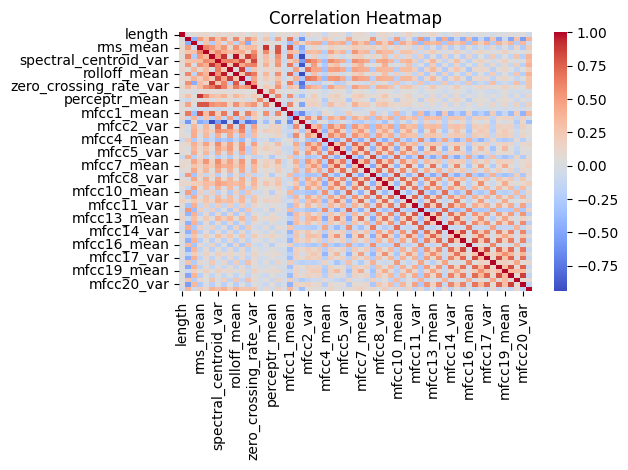

In [73]:
# Display the correlation matrix using a heatmap
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

From the Co Relation matrix and color distribution of the graph, it can be analyzed that there is no much colinearity between 2 columns.

# Detecting Outliers

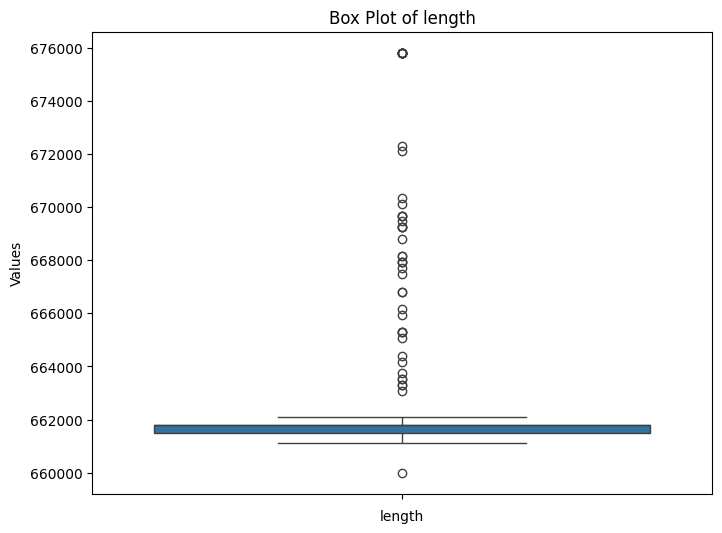

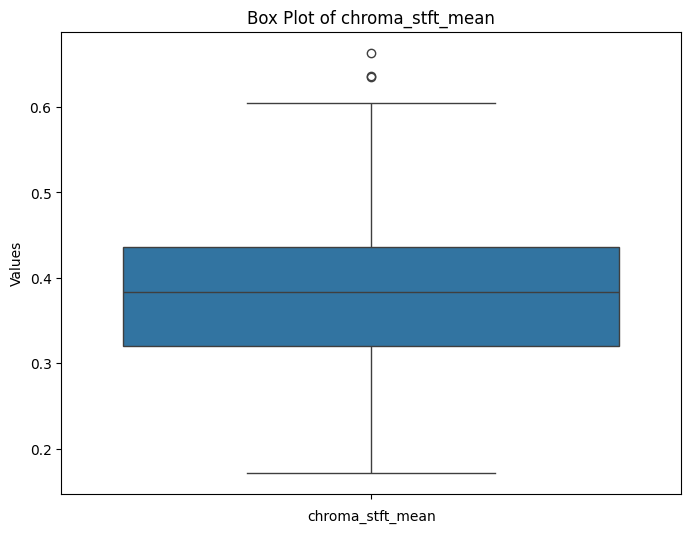

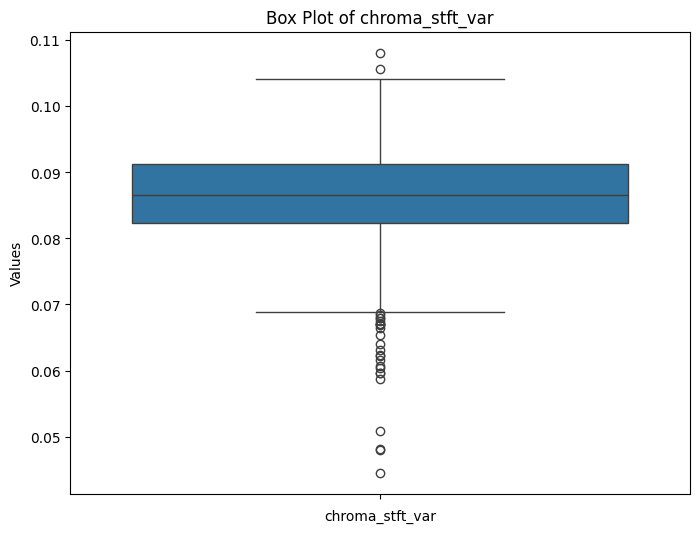

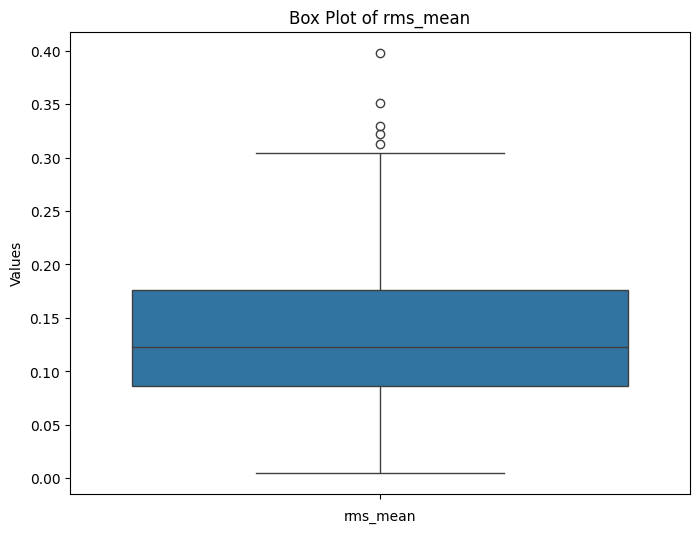

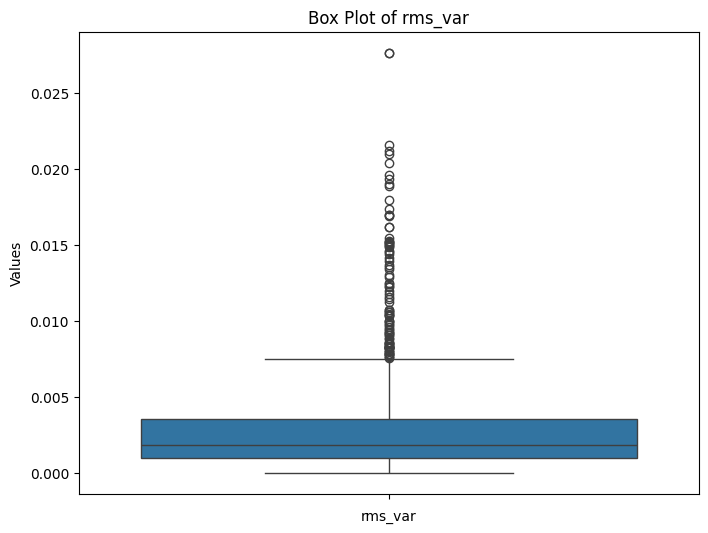

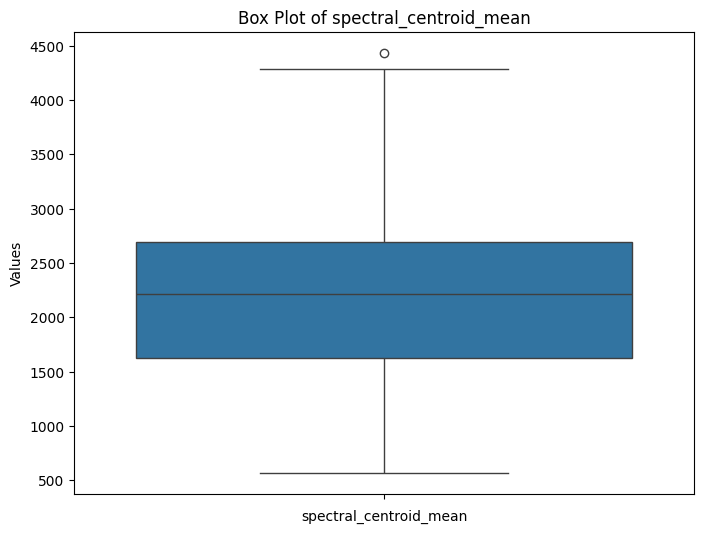

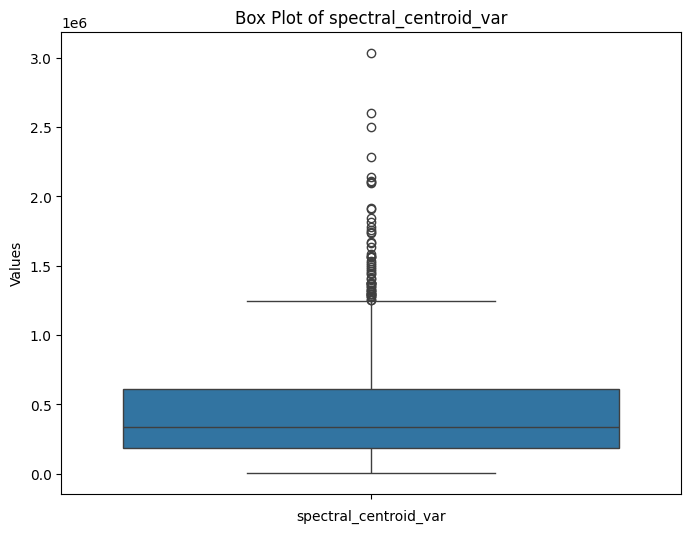

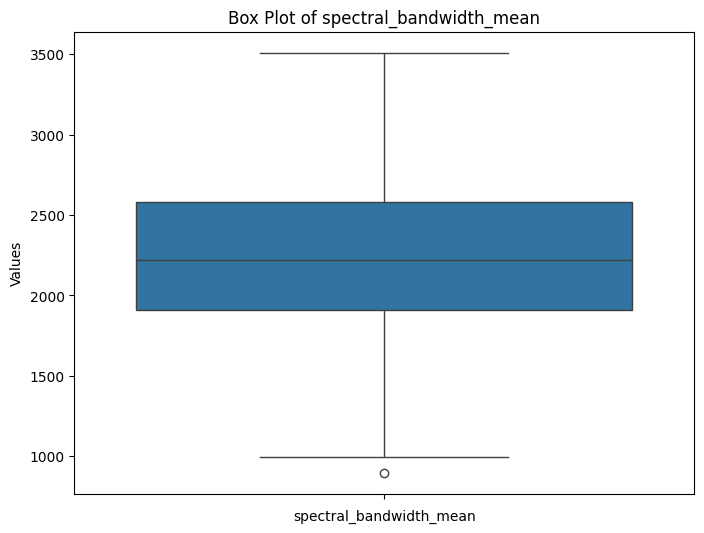

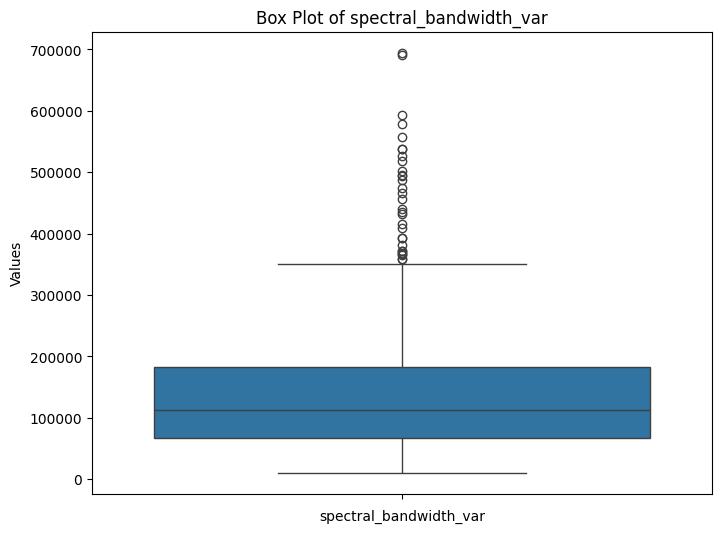

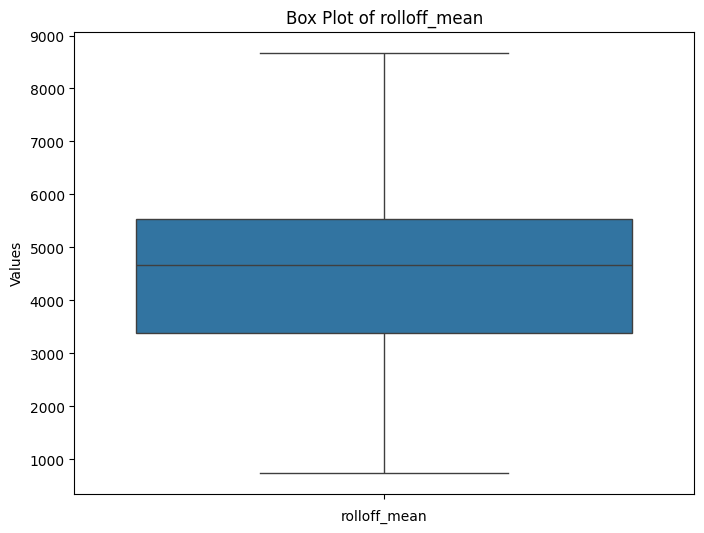

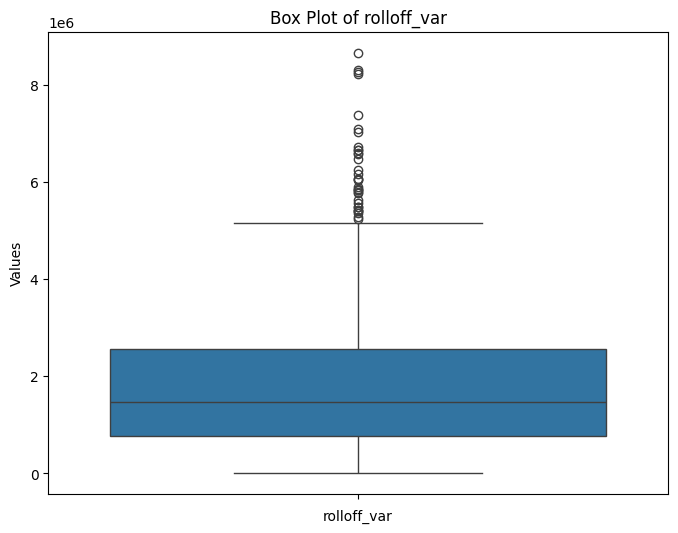

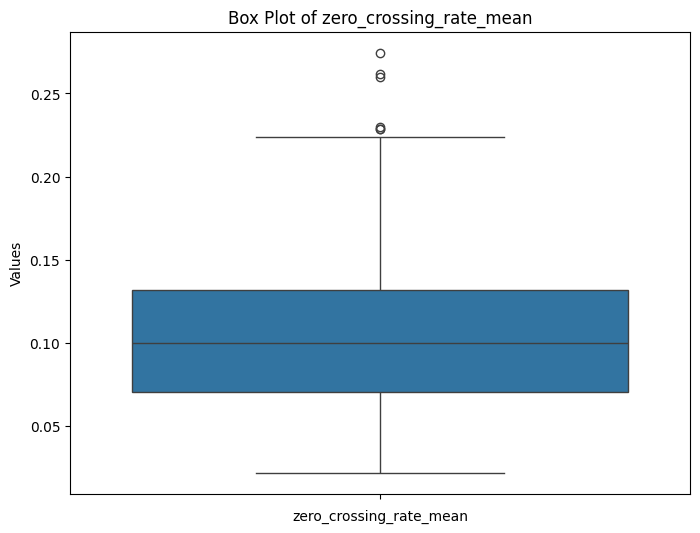

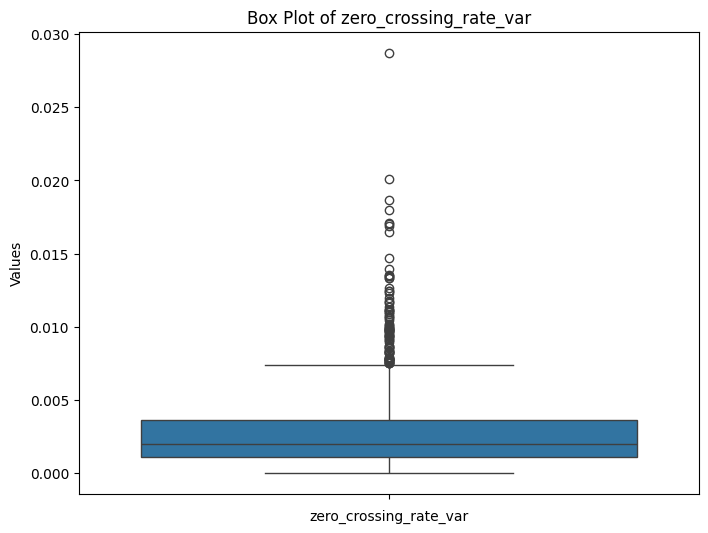

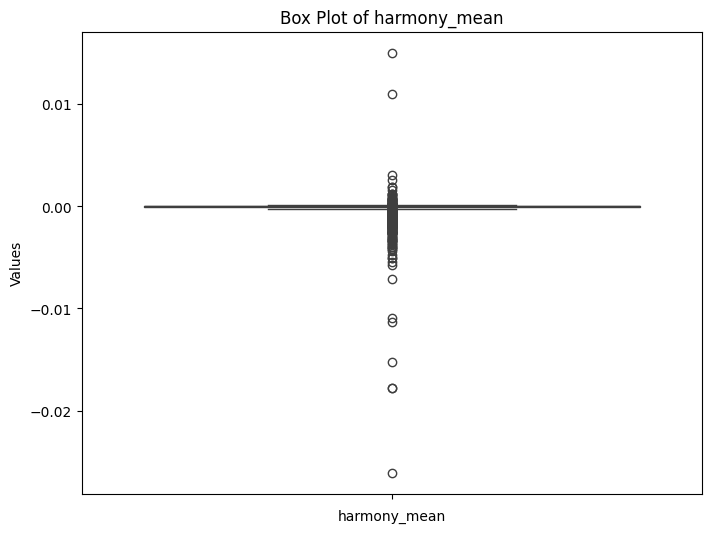

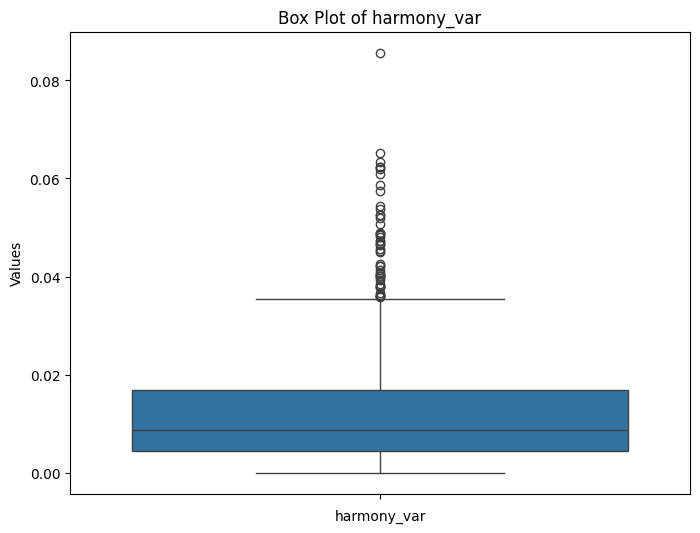

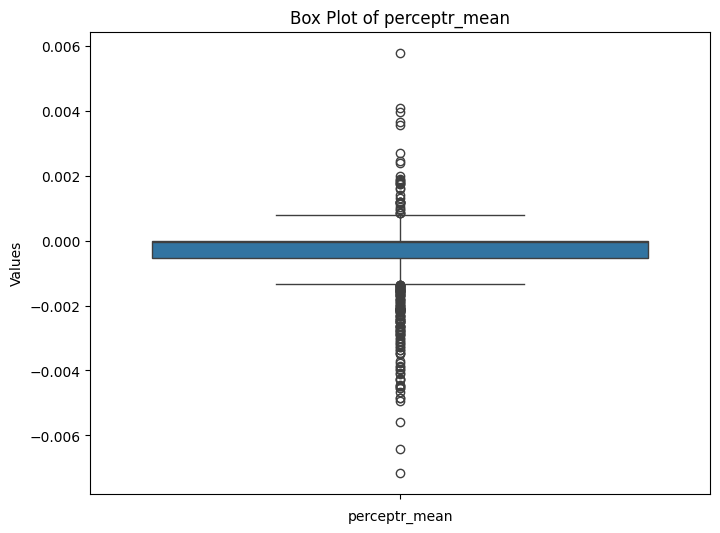

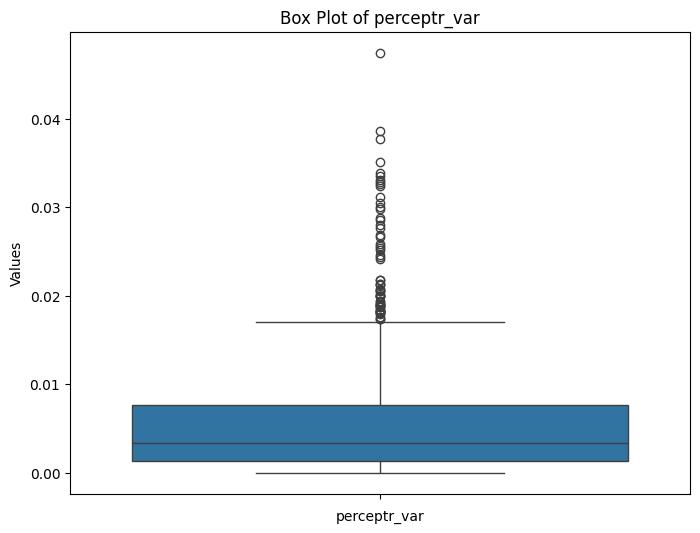

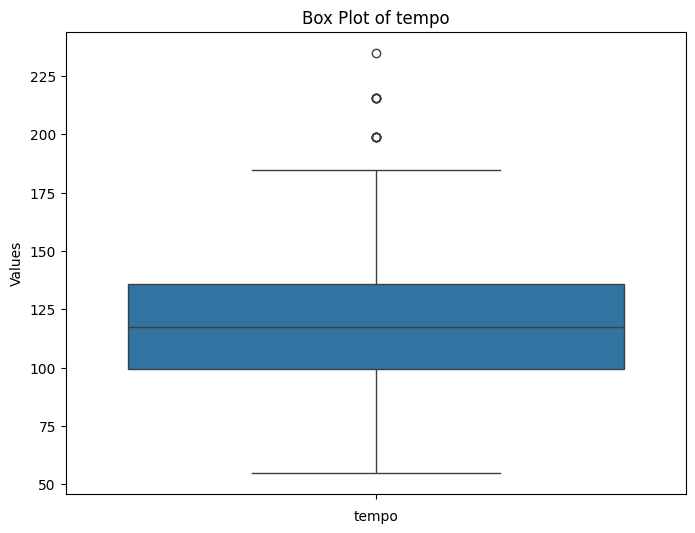

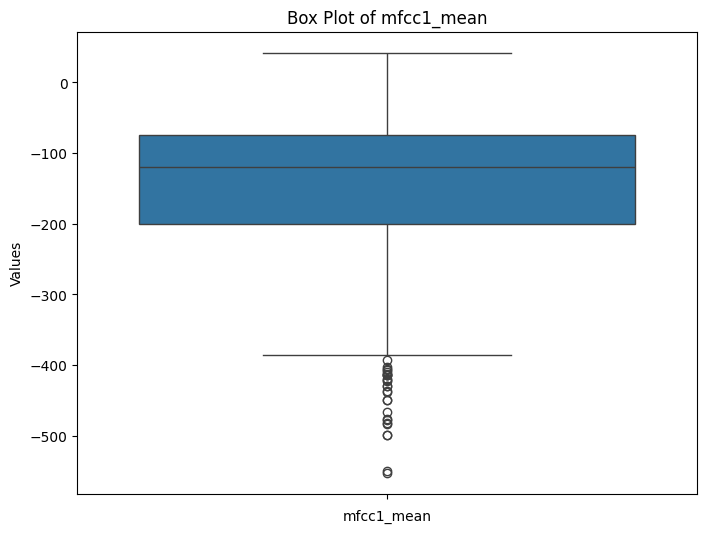

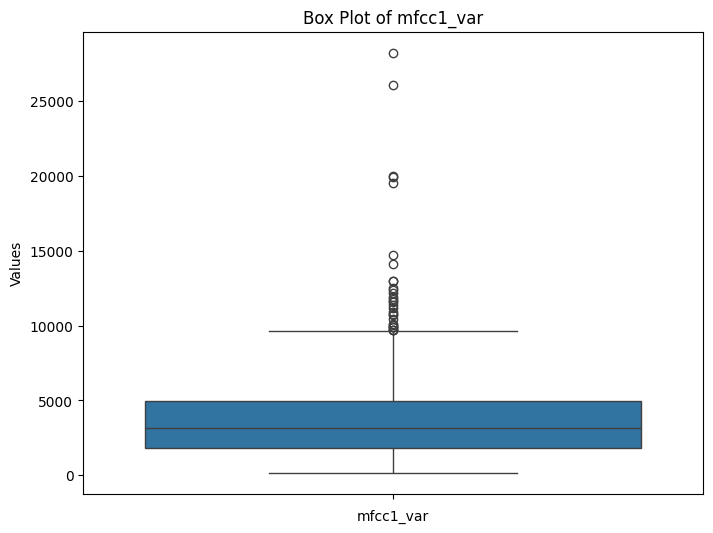

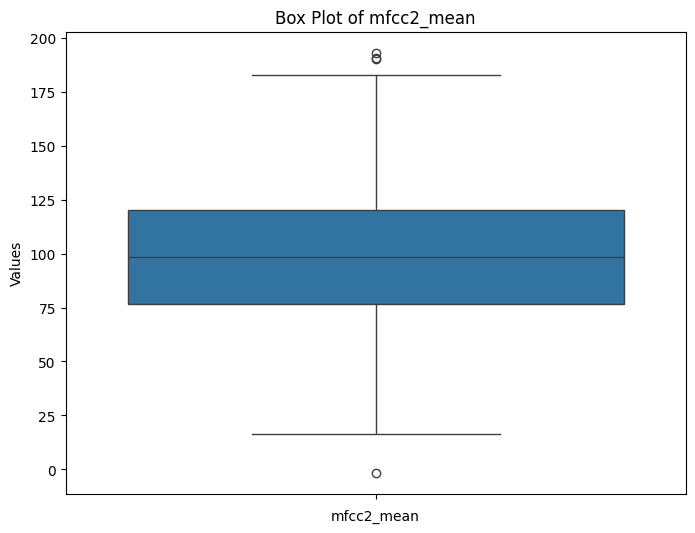

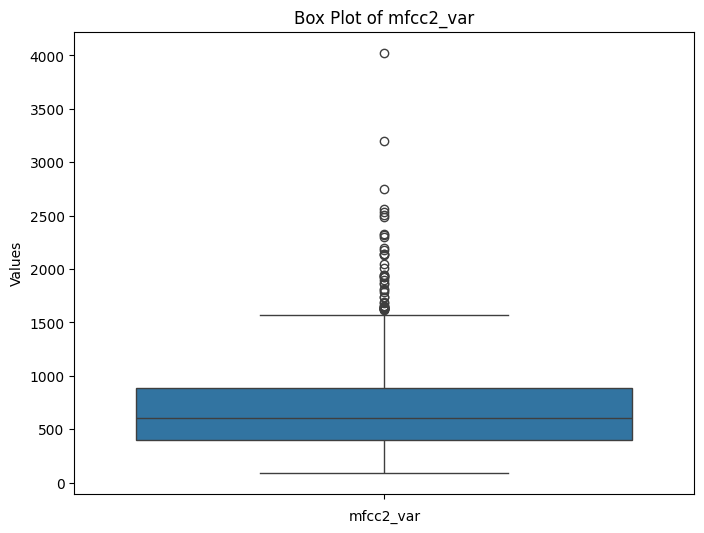

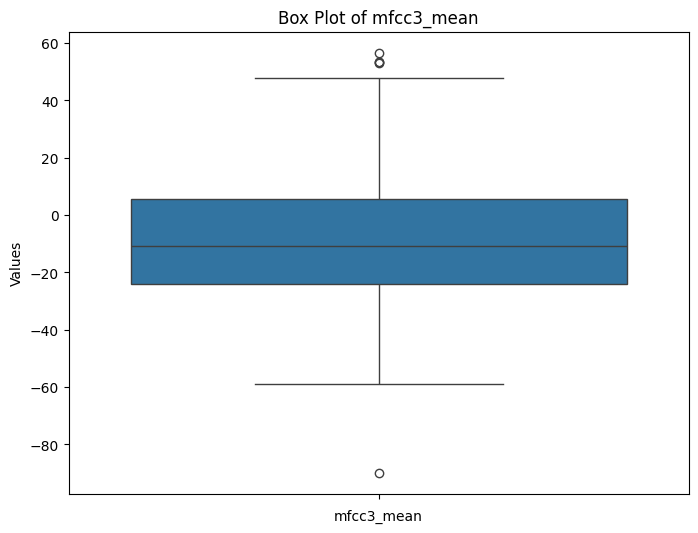

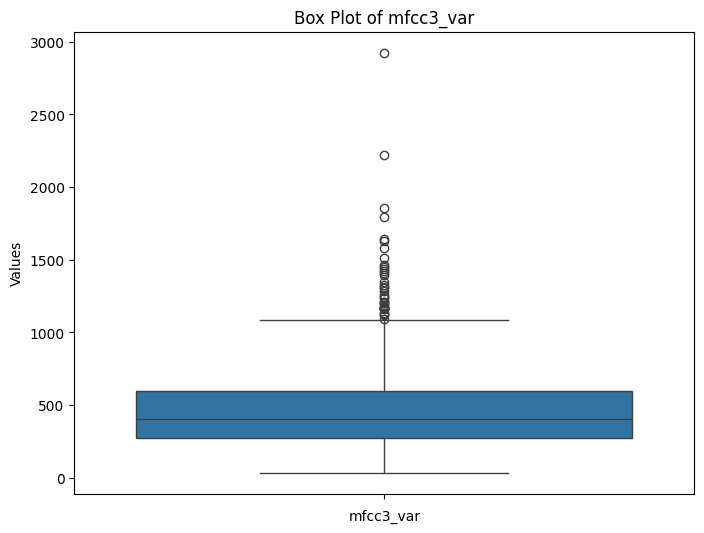

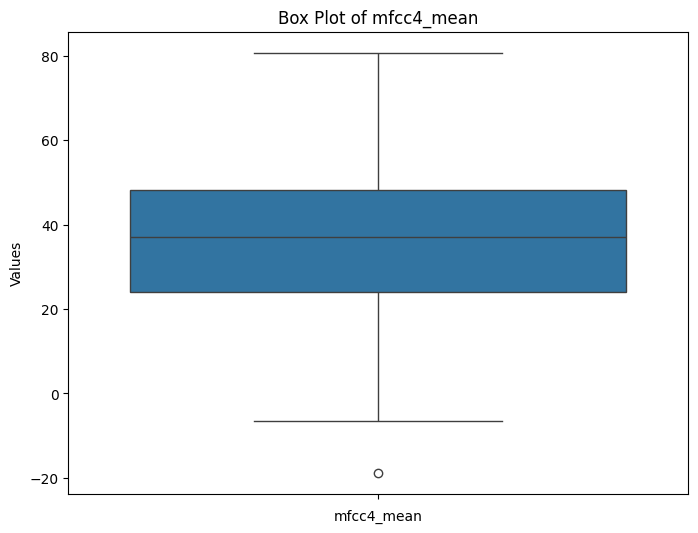

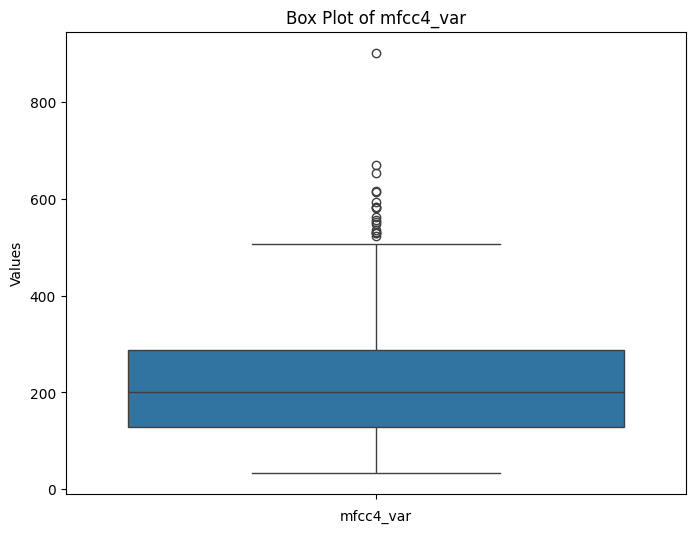

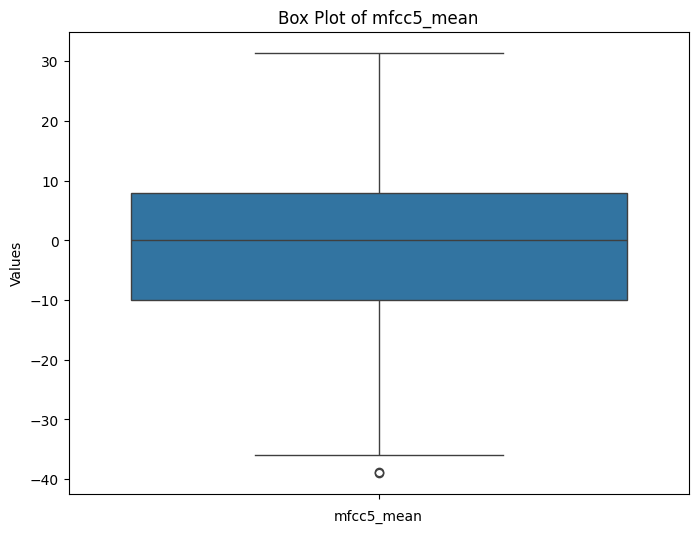

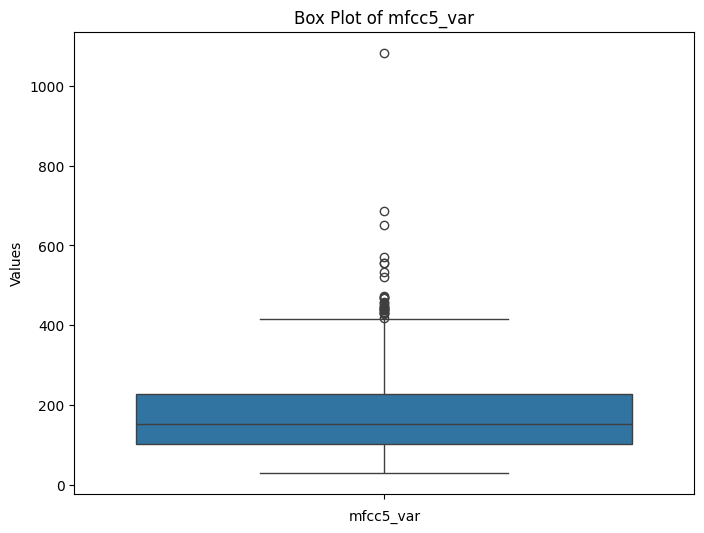

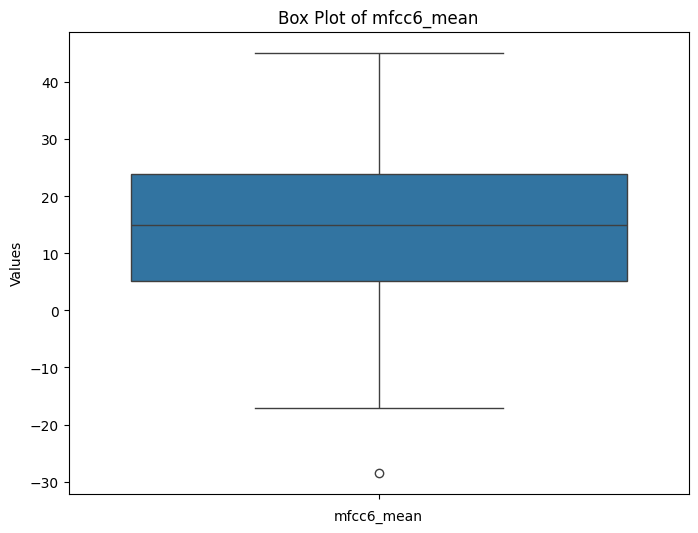

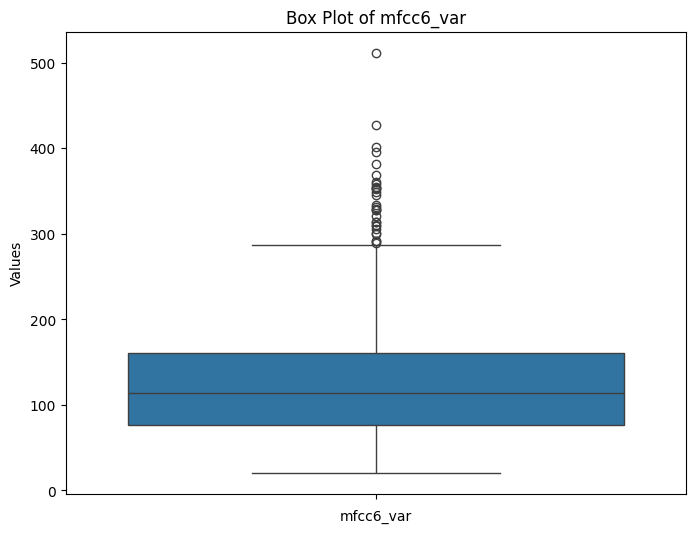

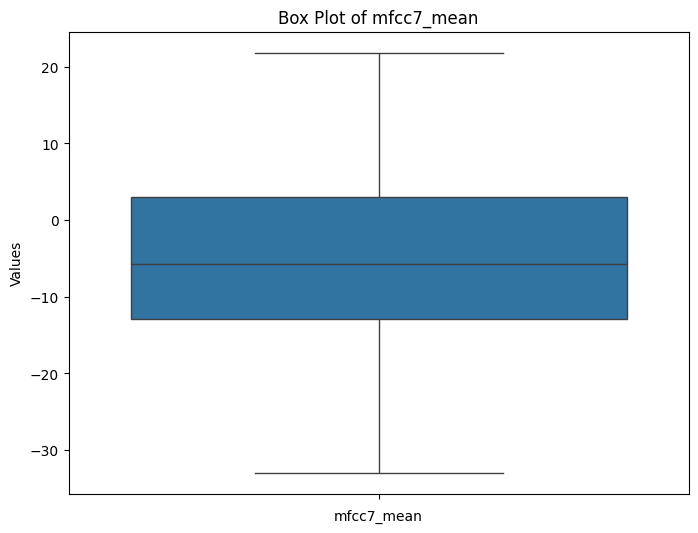

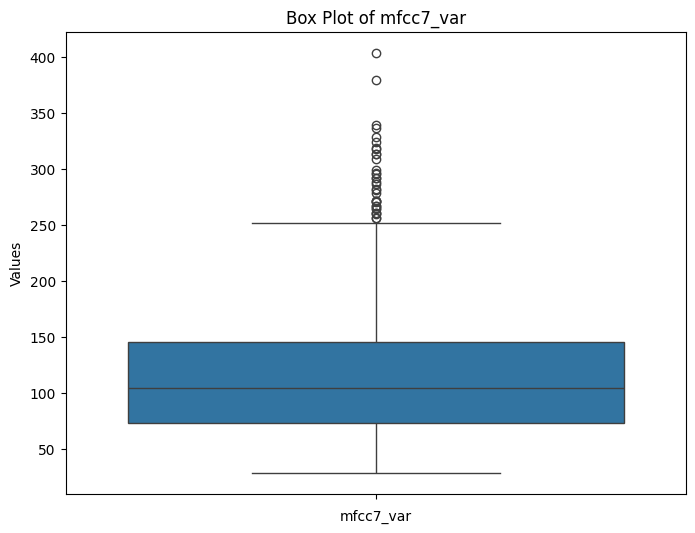

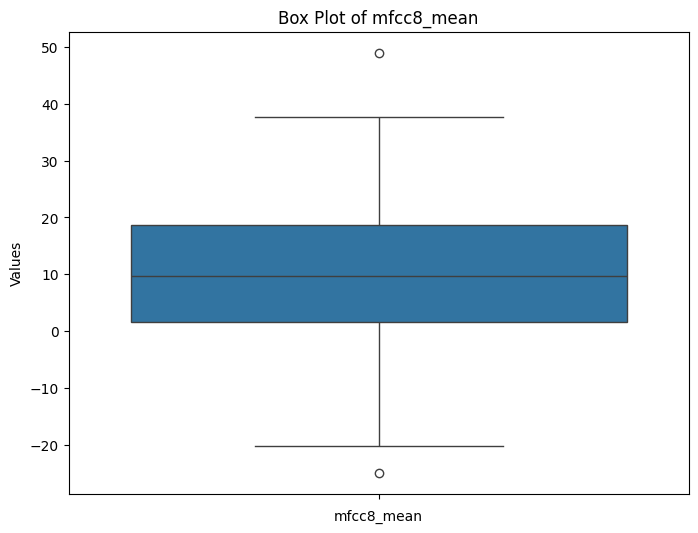

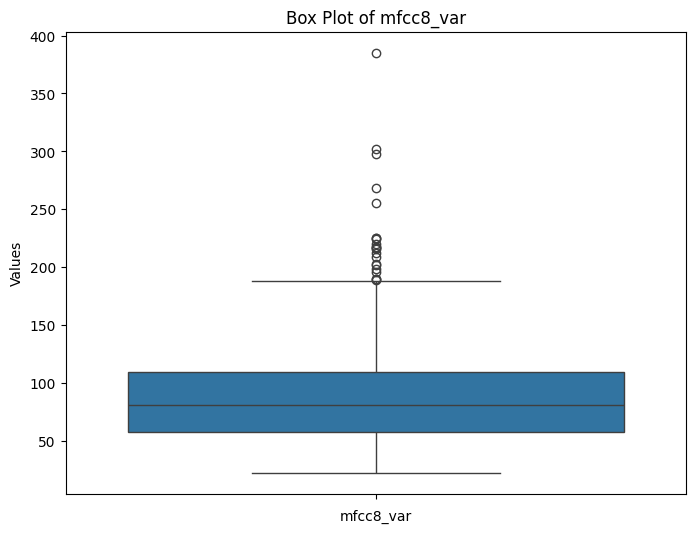

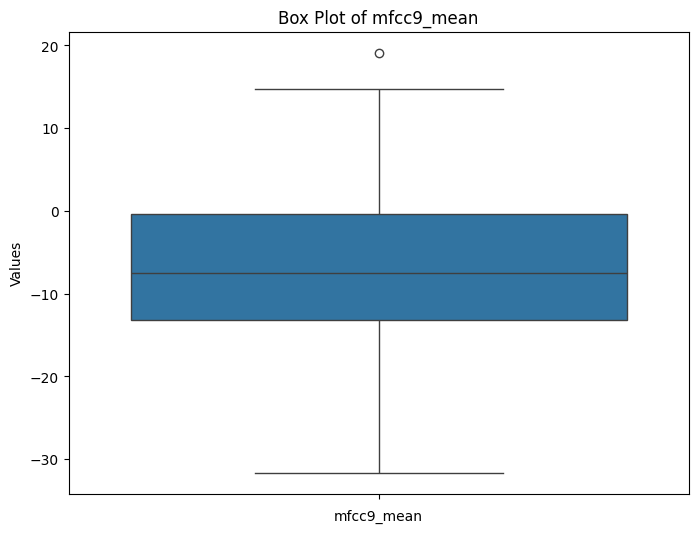

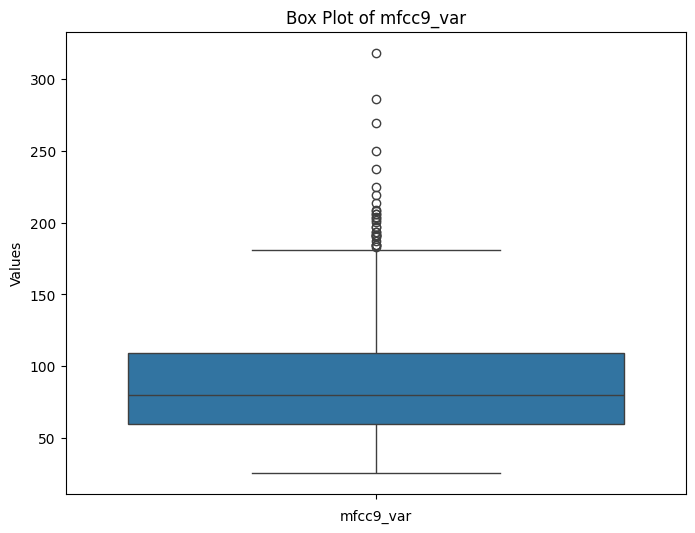

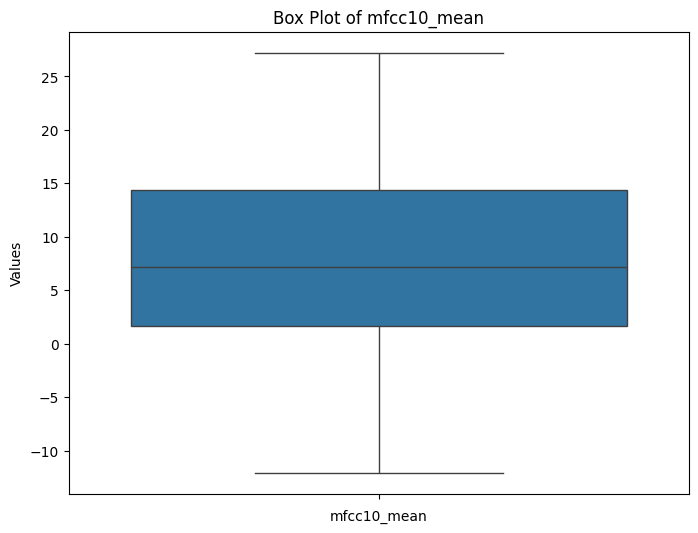

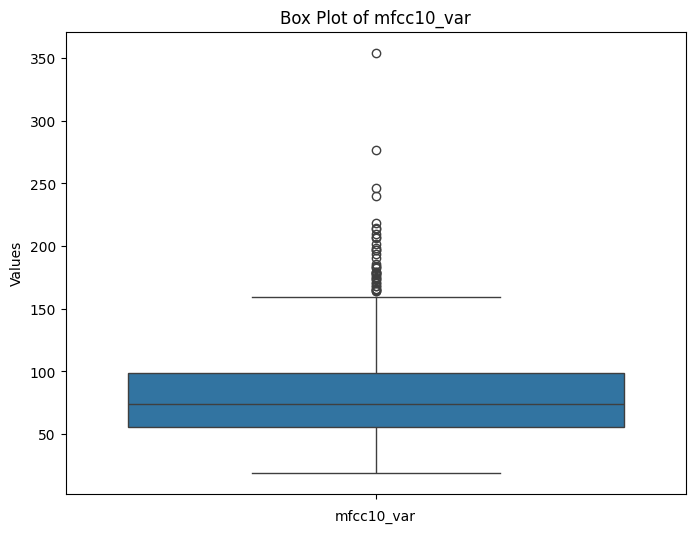

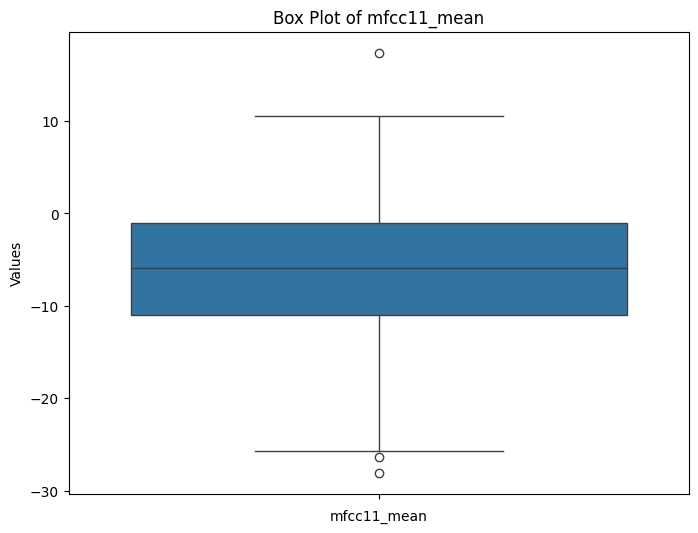

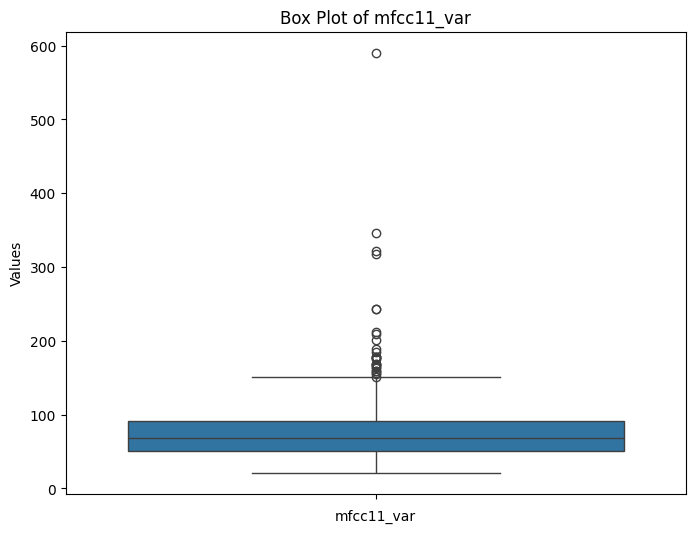

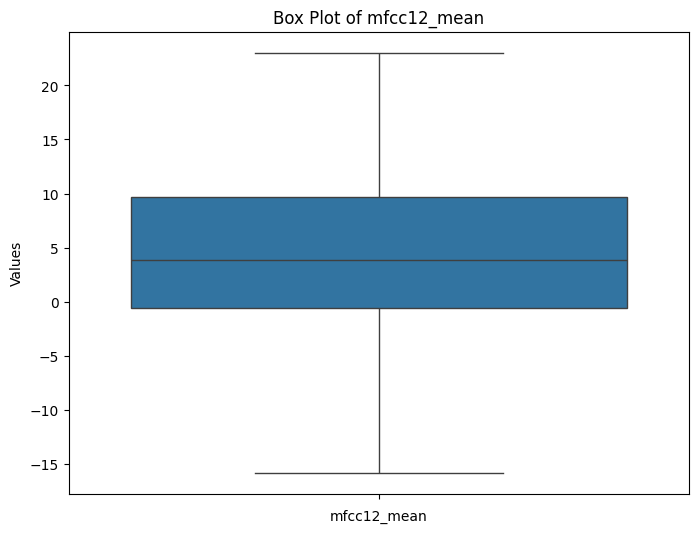

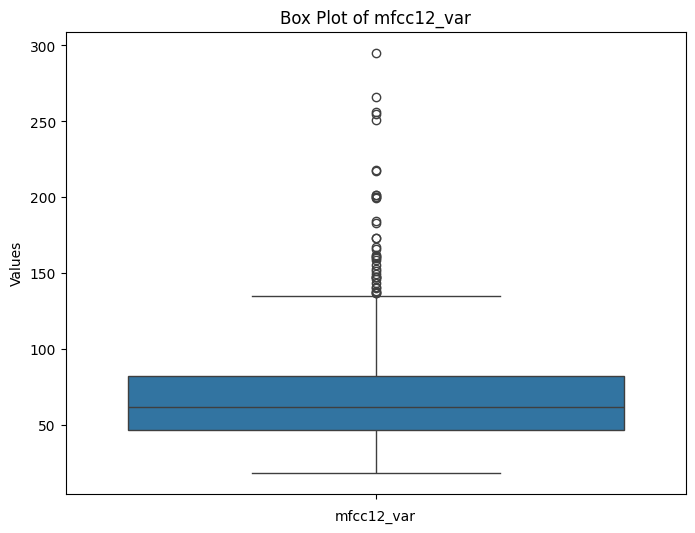

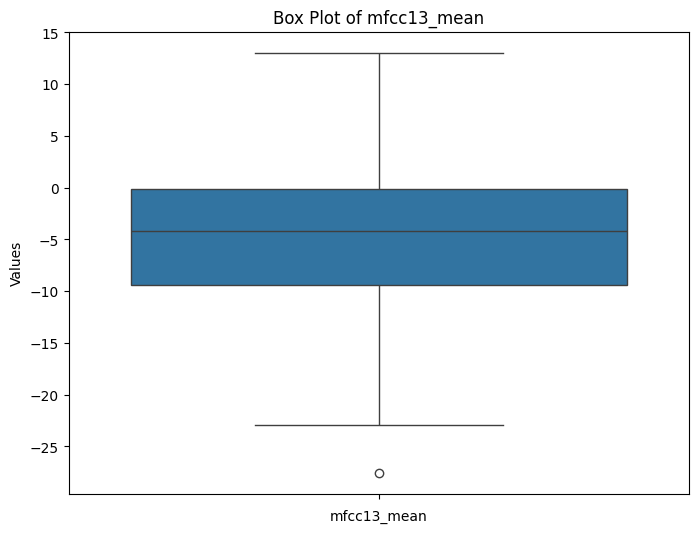

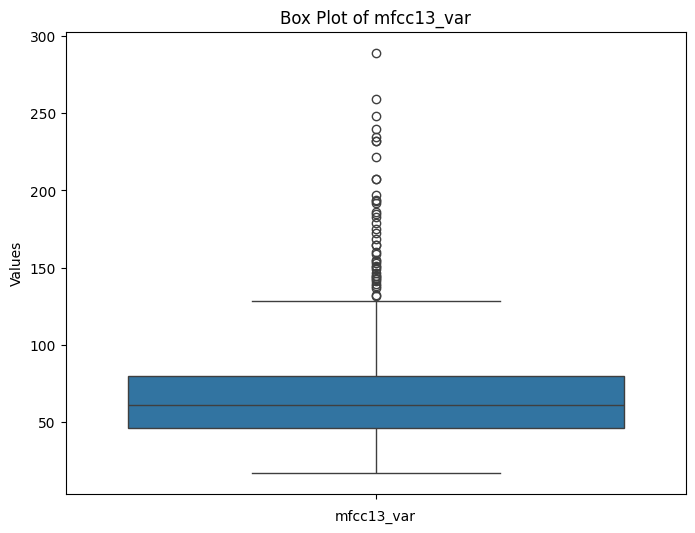

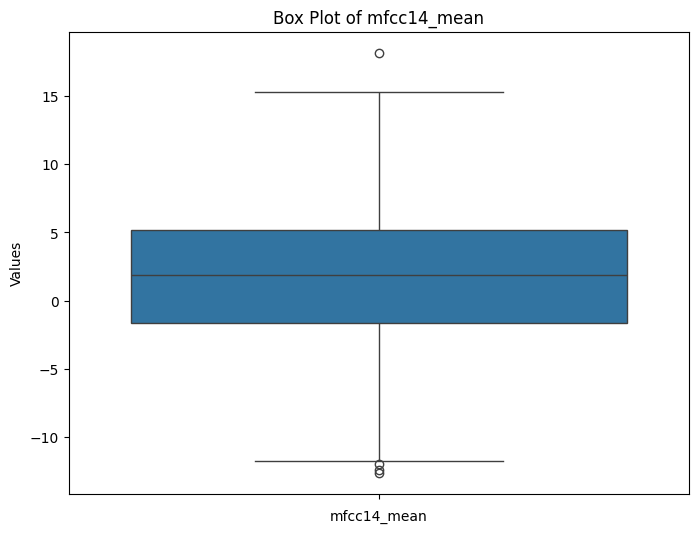

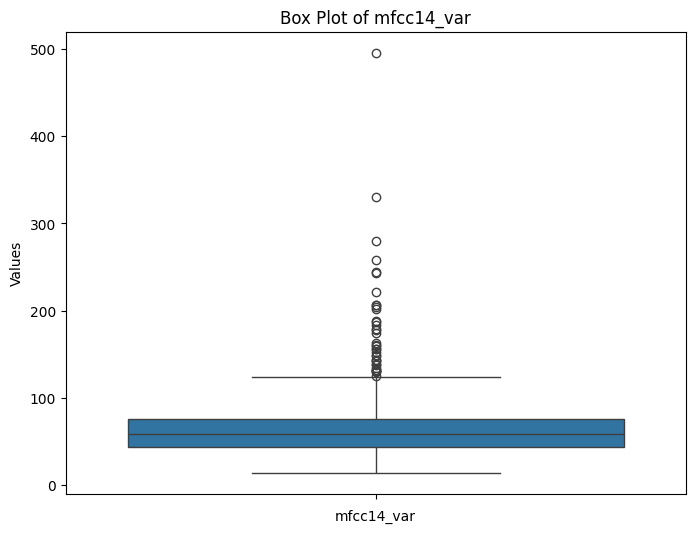

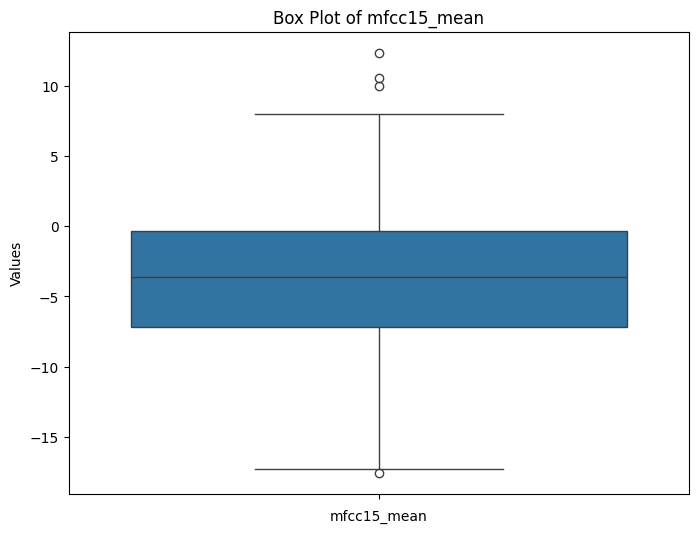

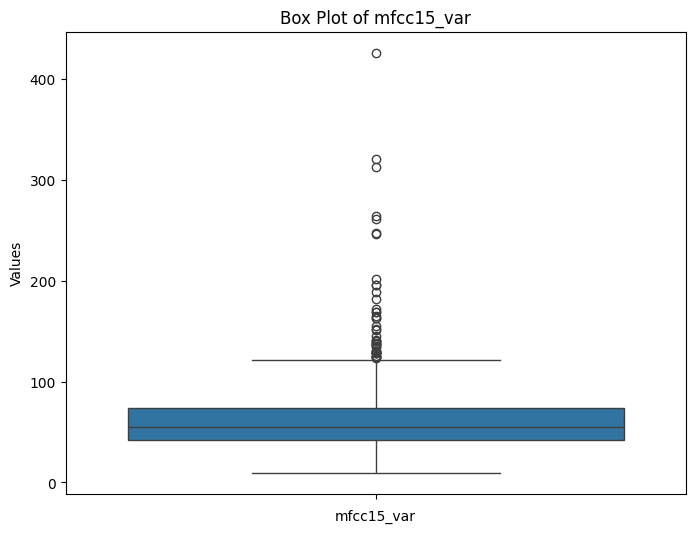

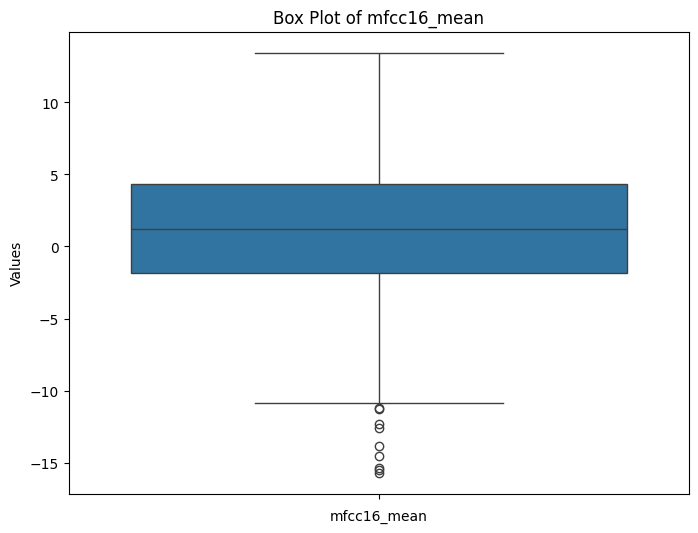

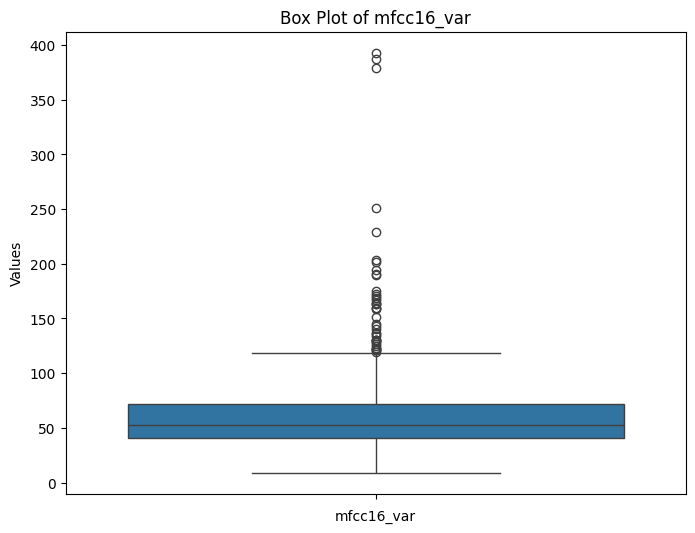

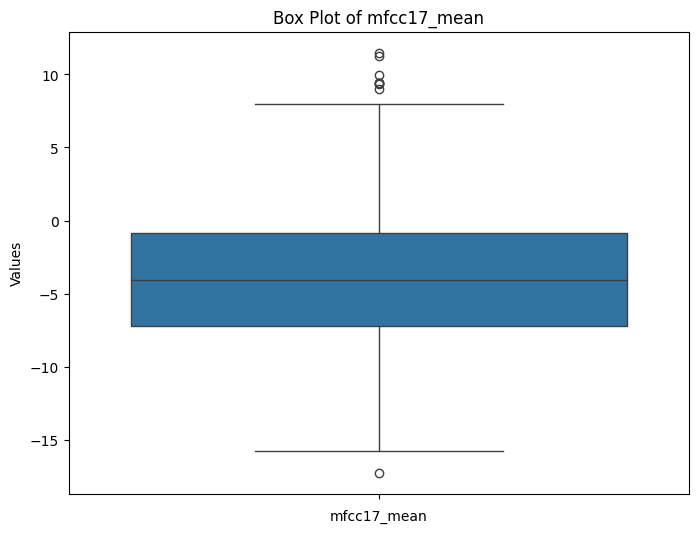

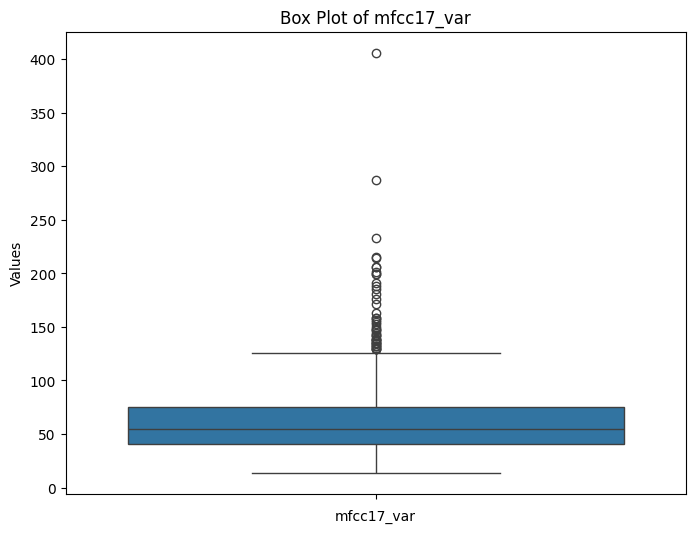

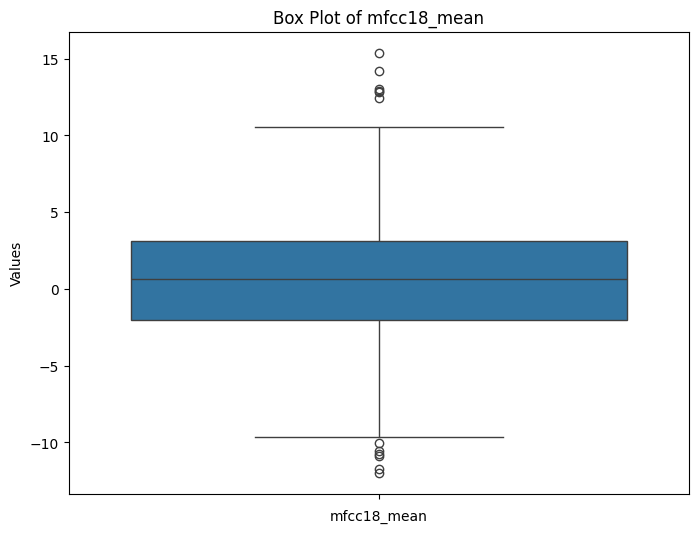

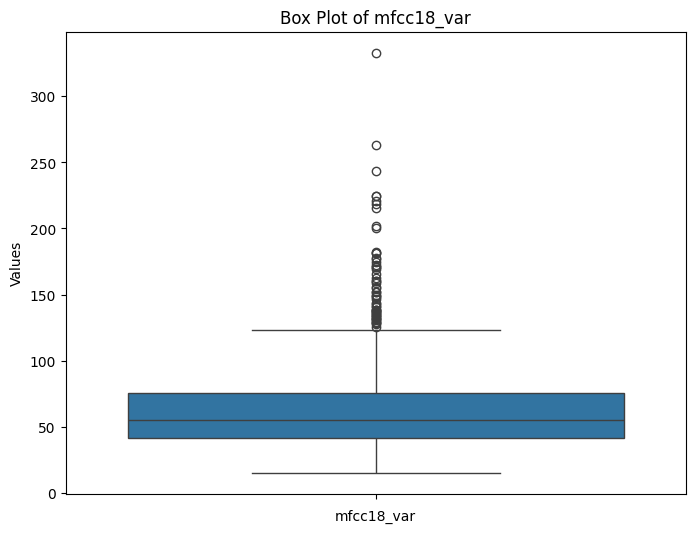

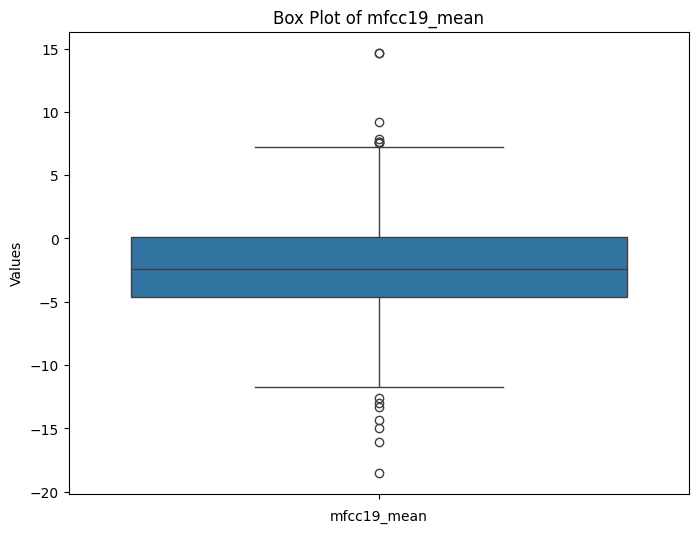

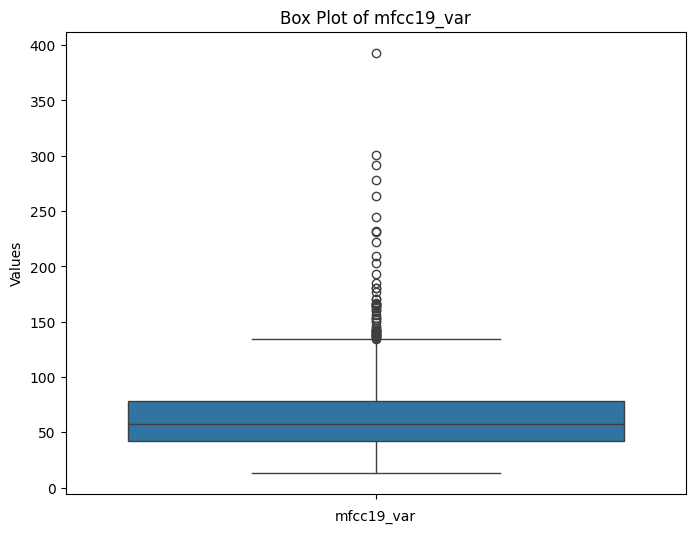

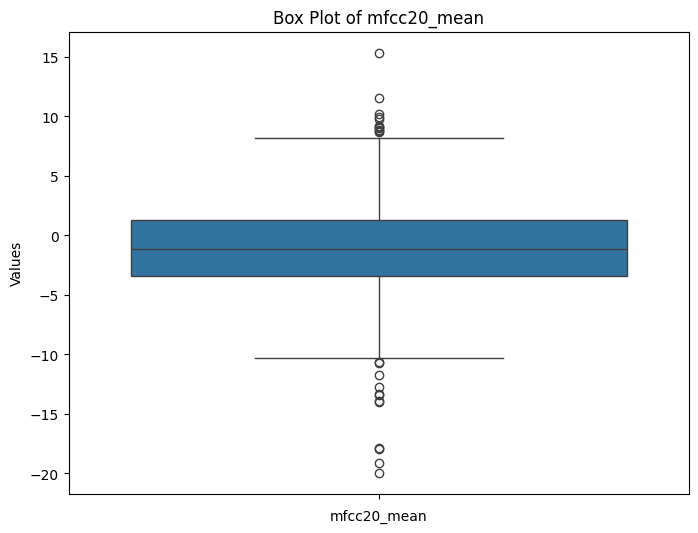

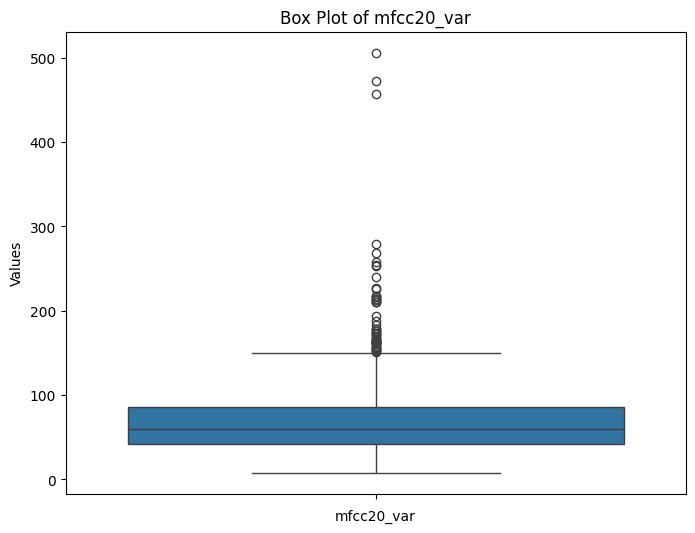

In [103]:
df3 = df2.drop(['genre_mapped'], axis=1)

# Create a box plot
for column in df3.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df3[column])
    
    # Add labels and title
    plt.title(f'Box Plot of {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Values')
    
    # Show the plot
    plt.show()

## Removing Outliers

In [104]:
def remove_outliers_iqr(df, column):
    # Calculate Q1 and Q3
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define the bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out the outliers
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    return filtered_df


In [108]:
filtered_data = df3.copy()

for column in df3.columns:
    filtered_data = remove_outliers_iqr(filtered_data, column)

print("\nFiltered Data (No Outliers):")
filtered_data.head()



Filtered Data (No Outliers):


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,3805.839606,...,0.752740,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035
2,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,3042.260232,...,2.451690,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025
3,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,2184.745799,...,0.780874,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339
8,661794,0.408879,0.086512,0.142416,0.001507,1719.368948,163282.845439,2031.740381,105542.718193,3782.316288,...,-1.452559,50.563751,-7.041824,28.894934,2.695248,36.889568,3.412305,33.698597,-2.715692,36.418430
17,661794,0.302124,0.093346,0.093306,0.002151,1088.844230,231640.777806,1410.984259,69795.442909,2134.992942,...,-4.773669,58.393814,-3.030989,65.709282,-1.994088,65.009689,-0.046754,62.942818,-3.971227,64.719292


In [109]:
len(filtered_data)

170

This shows that removing outliers removes a lot of the data. So we will be using a model that is not very sensitive to the outliers.

## Train Test Split

In [118]:
X = df2.drop(['genre_mapped'], axis = 1)
y = df2['genre_mapped']
len(X), len(y)

(1000, 1000)

In [119]:
# Step 1: Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Further split the training set into training and validation sets (75% train, 25% validation)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2


## Standard Scaler

In [120]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


## Models

### Random Forest Classifier

In [121]:
# Initialize and train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict on validation and test sets
y_val_pred_rf = rf_model.predict(X_val_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
print("****** Validation Set ************")
print("Random Forest Validation Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_val, y_val_pred_rf))

print("\n****** Test Set ************")
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_test_pred_rf))


****** Validation Set ************
Random Forest Validation Accuracy: 0.825
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.79      0.84        24
           1       0.86      0.86      0.86        22
           2       0.76      0.84      0.80        19
           3       0.83      0.71      0.77        21
           4       0.82      0.70      0.76        20
           5       0.84      0.84      0.84        25
           6       0.75      0.92      0.83        13
           7       0.92      0.96      0.94        24
           8       0.67      1.00      0.80        14
           9       0.86      0.67      0.75        18

    accuracy                           0.82       200
   macro avg       0.82      0.83      0.82       200
weighted avg       0.83      0.82      0.82       200


****** Test Set ************
Random Forest Test Accuracy: 0.74
Random Forest Classification Report:
               precision  

### Bagging Classifer

In [131]:
# Initialize and train Bagging Classifier model
bagging_model = BaggingClassifier( n_estimators=50, random_state=42)
bagging_model.fit(X_train_scaled, y_train)

# Predict on validation and test sets
y_val_pred_bagging = bagging_model.predict(X_val_scaled)
y_test_pred_bagging = bagging_model.predict(X_test_scaled)

# Evaluate the model
print("****** Validation Set ************")
print("Bagging Classifier Validation Accuracy:", accuracy_score(y_val, y_val_pred_bagging))
print("Bagging Classifier Classification Report:\n", classification_report(y_val, y_val_pred_bagging))

print("\n****** Test Set ************")
print("Bagging Classifier Test Accuracy:", accuracy_score(y_test, y_test_pred_bagging))
print("Bagging Classifier Classification Report:\n", classification_report(y_test, y_test_pred_bagging))


****** Validation Set ************
Bagging Classifier Validation Accuracy: 0.78
Bagging Classifier Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.79      0.86        24
           1       0.79      0.86      0.83        22
           2       0.64      0.74      0.68        19
           3       0.71      0.71      0.71        21
           4       0.80      0.60      0.69        20
           5       0.82      0.72      0.77        25
           6       0.71      0.77      0.74        13
           7       0.88      0.96      0.92        24
           8       0.76      0.93      0.84        14
           9       0.68      0.72      0.70        18

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.77       200
weighted avg       0.79      0.78      0.78       200


****** Test Set ************
Bagging Classifier Test Accuracy: 0.685
Bagging Classifier Classification Report:
      

## Model Evaluation

### Accuracy Comparison

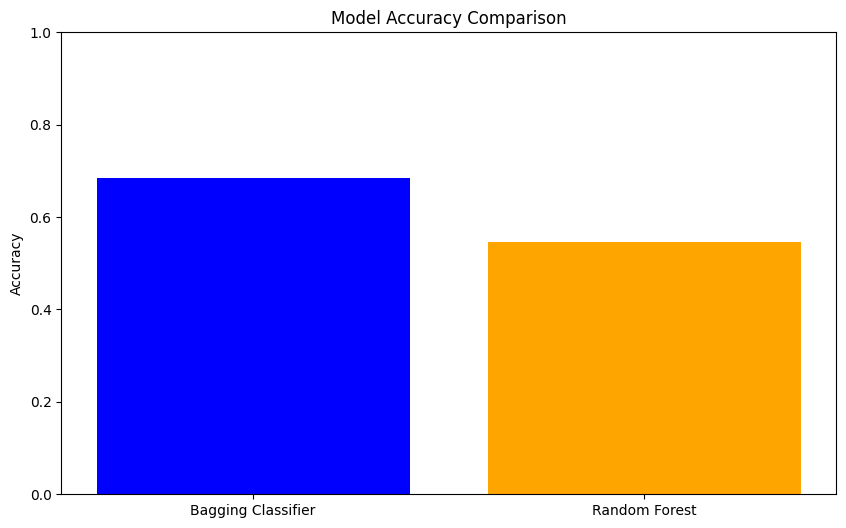

In [132]:
# Accuracy scores
accuracy_bagging = accuracy_score(y_test, y_test_pred_bagging)
y_test_pred_rf = accuracy_score(y_test, y_test_pred_dt)

# Plotting
models = ['Bagging Classifier', 'Random Forest']
accuracies = [accuracy_bagging, accuracy_dt]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'orange'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim([0, 1])
plt.show()


In terms of accuracy, Bagging Classifier is better than Random Forest.

# Saving The Model

In [137]:
# Save the trained model to a file
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(bagging_model, file)

In [138]:
# Save the Scaler model to a file
with open('StandardScaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# Making Prediction

In [44]:
with open('random_forest_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
with open('StandardScaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)

In [45]:
audio_path = "./genres_original/blues/blues.00000.wav"
audio, sr = PreProcessing(audio_path)
features = extract_features(audio, sr)

In [46]:
features_DataFrame = pd.DataFrame(features)
features_DataFrame

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc11_var,mfcc12_var,mfcc13_var,mfcc14_var,mfcc15_var,mfcc16_var,mfcc17_var,mfcc18_var,mfcc19_var,mfcc20_var
0,661770,0.350063,0.085059,0.130179,0.00283,1784.708862,130171.768099,2002.543629,86015.55302,3807.318038,...,62.057774,51.287086,41.368706,40.474274,49.702129,52.38427,36.452038,41.611271,54.997475,46.934464


In [52]:
new_order = ['length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var' ,'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var' ]

df_reordered = features_DataFrame.reindex(columns=new_order)
df_reordered

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,661770,0.350063,0.085059,0.130179,0.00283,1784.708862,130171.768099,2002.543629,86015.55302,3807.318038,...,0.663658,52.38427,-1.612964,36.452038,-0.457087,41.611271,-2.237828,54.997475,1.17636,46.934464


In [55]:
scaled_features = loaded_scaler.transform(df_reordered)
scaled_features

array([[-1.27062616e-01, -3.77942370e-01, -1.78690790e-01,
        -2.32124887e-02, -7.62718048e-02, -5.87292581e-01,
        -8.50524665e-01, -4.69649199e-01, -5.45386412e-01,
        -4.93007484e-01, -6.67734452e-01, -4.89961210e-01,
        -7.57366063e-01,  2.11139625e-01, -3.78390080e-01,
         2.19426745e+04,  4.03489869e+04,  1.19395499e-01,
         3.00622835e-01, -4.39443625e-01,  6.92825960e-01,
        -9.21193346e-01, -5.09965112e-01, -8.78749979e-01,
         3.88458422e-01, -5.96358809e-01, -4.26152384e-01,
        -5.20716465e-02,  3.53757633e-01, -5.46475076e-01,
        -8.76106268e-01, -8.21433008e-01,  5.11942463e-01,
        -4.58468332e-01, -6.39624020e-01, -1.42346827e-01,
         4.23225365e-01, -4.92817017e-01, -3.32522570e-01,
        -3.23197277e-01,  6.56531795e-01, -5.16625112e-01,
         1.77850955e-01, -7.78413909e-01,  8.07853043e-01,
        -7.34508478e-01, -2.39102480e-01, -3.87217300e-01,
        -6.62537342e-02, -2.19643068e-01,  4.92437970e-0

In [56]:
loaded_model.predict(scaled_features) # True Prediction

array([0])